In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# Random Seed 고정 (재현성 확보)
torch.manual_seed(42)

# ==========================================
# 1. CNN 모델 정의 (구조 명확화)
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Block 1: 1x28x28 -> 12x14x14
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 12, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Block 2: 12x14x14 -> 24x7x7
        self.layer2 = nn.Sequential(
            nn.Conv2d(12, 24, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Classifier
        self.fc = nn.Linear(24 * 7 * 7, 10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1) # Flatten
        out = self.fc(out)
        return out

# ==========================================
# 2. 데이터셋 준비 (Fashion MNIST)
# ==========================================
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# 학습 데이터
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# 테스트 데이터
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True) # 시각화를 위해 배치 1

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

# ==========================================
# 3. 학습 (Training Loop)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Start Training...")
model.train()
for epoch in range(3):  # 시간 관계상 3 Epoch만
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f'[Epoch {epoch + 1}] Loss: {running_loss / len(trainloader):.4f}')

print("Training Finished!")

Start Training...
[Epoch 1] Loss: 0.5182
[Epoch 2] Loss: 0.3408
[Epoch 3] Loss: 0.3020
Training Finished!


/tmp/ipython-input-1038494015.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.93])


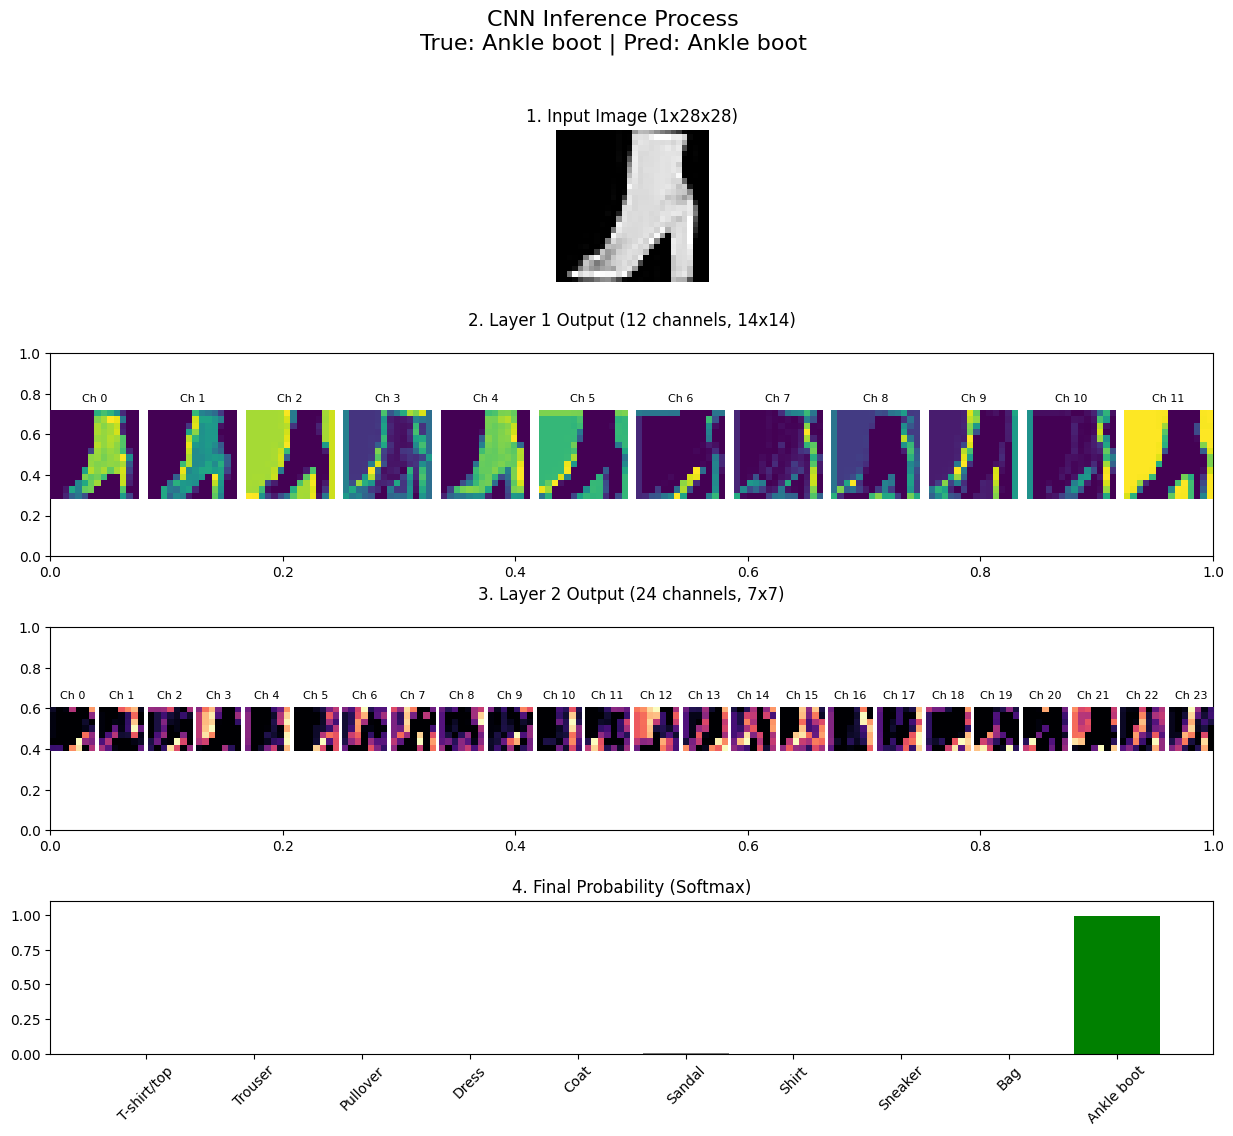

In [ ]:
def visualize_inference(model, sample_image, true_label):
    model.eval()

    # -------------------------------------------------
    # 단계별 추론
    # -------------------------------------------------
    with torch.no_grad():
        x = sample_image.unsqueeze(0).to(device)
        out1 = model.layer1(x)
        out2 = model.layer2(out1)
        flat = out2.view(out2.size(0), -1)
        logits = model.fc(flat)
        probs = torch.nn.functional.softmax(logits, dim=1)
        pred_label = torch.argmax(probs, dim=1).item()

    # -------------------------------------------------
    # 시각화 (GridSpec을 활용한 레이아웃 개선)
    # -------------------------------------------------
    fig = plt.figure(figsize=(15, 12))
    fig.suptitle(f"CNN Inference Process\nTrue: {classes[true_label]} | Pred: {classes[pred_label]}", fontsize=16, y=0.98)

    # 전체를 4개의 행으로 나눕니다. 높이 비율을 다르게 설정합니다.
    outer_gs = gridspec.GridSpec(4, 1, height_ratios=[1.5, 2, 2, 1.5], hspace=0.4)

    # [ROW 1] 원본 이미지
    ax0 = fig.add_subplot(outer_gs[0])
    ax0.imshow(sample_image.squeeze(), cmap='gray')
    ax0.set_title(f"1. Input Image (1x28x28)")
    ax0.axis('off')

    # [ROW 2] Layer 1 Output (Feature Maps) - 12개 채널
    # 내부 GridSpec을 만들어 1행 12열로 나눕니다.
    inner_gs1 = gridspec.GridSpecFromSubplotSpec(1, 12, subplot_spec=outer_gs[1], wspace=0.1)
    fig.add_subplot(outer_gs[1]).set_title(f"2. Layer 1 Output (12 channels, 14x14)", pad=20) # 전체 타이틀용 가짜 서브플롯
    fig.add_subplot(outer_gs[1]).axis('off') # 축 숨기기

    layer1_maps = out1.cpu().squeeze()
    for i in range(12):
        ax = fig.add_subplot(inner_gs1[i])
        ax.imshow(layer1_maps[i], cmap='viridis')
        ax.axis('off')
        ax.set_title(f'Ch {i}', fontsize=8)

    # [ROW 3] Layer 2 Output (Feature Maps) - 24개 채널
    # 내부 GridSpec을 만들어 1행 24열로 나눕니다.
    inner_gs2 = gridspec.GridSpecFromSubplotSpec(1, 24, subplot_spec=outer_gs[2], wspace=0.1)
    fig.add_subplot(outer_gs[2]).set_title(f"3. Layer 2 Output (24 channels, 7x7)", pad=20) # 전체 타이틀용 가짜 서브플롯
    fig.add_subplot(outer_gs[2]).axis('off')

    layer2_maps = out2.cpu().squeeze()
    for i in range(24):
        ax = fig.add_subplot(inner_gs2[i])
        ax.imshow(layer2_maps[i], cmap='magma')
        ax.axis('off')
        ax.set_title(f'Ch {i}', fontsize=8)

    # [ROW 4] Classification Result
    ax3 = fig.add_subplot(outer_gs[3])
    probs_np = probs.cpu().squeeze().numpy()
    colors = ['gray'] * 10
    colors[pred_label] = 'red'
    colors[true_label] = 'green'

    ax3.bar(classes, probs_np, color=colors)
    ax3.set_title("4. Final Probability (Softmax)")
    ax3.set_ylim(0, 1.1)
    plt.xticks(rotation=45)

    # tight_layout이 겹침을 방지하도록 설정합니다.
    # rect 파라미터로 전체적인 여백을 조절합니다. [left, bottom, right, top]
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()

# -------------------------------------------------
# 실행
# -------------------------------------------------
dataiter = iter(testloader)
images, labels = next(dataiter)

# 모델의 채널 수를 시각화에 맞게 줄였습니다 (32->12, 64->24).
visualize_inference(model, images[0], labels[0].item())

In [ ]:
# ==========================================
# 2. 3D 그리기 도우미 함수들 (축 변경: Z -> X)
# ==========================================
def normalize_data(data):
    return (data - data.min()) / (data.max() - data.min() + 1e-6)

def plot_feature_blocks_horizontal(ax, tensor, x_pos, spacing=0.5, cmap='viridis'):
    """이미지를 Y-Z 평면에 세워서 X축을 따라 배치"""
    C, H, W = tensor.shape
    np_tensor = tensor.cpu().numpy()

    # Y(가로), Z(세로) 그리드 생성 (이미지를 세움)
    yy, zz = np.meshgrid(np.linspace(0, W, W), np.linspace(0, H, H))

    # 채널들을 X축 방향으로 약간씩 띄워서 배치
    x_start = x_pos - (C * spacing) / 2

    surfaces = []
    for c in range(C):
        layer_data = np_tensor[c]
        norm_data = normalize_data(layer_data)

        # X 좌표는 고정 (약간의 간격)
        xx = np.full_like(yy, x_start + c * spacing)

        # 순서 주의: plot_surface(X, Y, Z)
        surf = ax.plot_surface(xx, yy, zz, rstride=1, cstride=1,
                               facecolors=plt.get_cmap(cmap)(norm_data),
                               shade=False, alpha=0.8)
        surfaces.append(surf)
    return surfaces

def plot_flatten_line_horizontal(ax, tensor, x_pos, scale=0.05):
    """Flatten 데이터를 Y축을 따라 길게 배치 (X는 고정)"""
    np_data = tensor.cpu().numpy()
    N = len(np_data)
    norm_data = normalize_data(np_data)

    # Y축으로 길게 나열
    ys = np.arange(N) * scale
    # 중심을 맞추기 위해 Y축 이동
    ys = ys - (ys.max() / 2) + 14

    # X는 고정, Z는 중간 높이
    xs = np.full(N, x_pos)
    zs = np.full(N, 14)

    scatter = ax.scatter(xs, ys, zs, c=norm_data, cmap='inferno', s=5)
    return scatter

def plot_output_bars_horizontal(ax, tensor, x_pos, classes_list):
    """확률 막대를 X축 끝에 배치 (Y축으로 나열, Z축으로 높이)"""
    probs = tensor.cpu().numpy()
    num_classes = len(probs)

    # Y축 방향으로 클래스 배치
    ys = np.arange(num_classes) * 3
    ys = ys - (ys.max() / 2) + 14 # 중앙 정렬

    xs = np.full(num_classes, x_pos)
    zs = np.zeros(num_classes) # 바닥에서 시작

    dx = np.ones(num_classes) * 2  # 두께
    dy = np.ones(num_classes) * 2
    dz = probs * 20 # 높이

    colors = ['blue'] * num_classes
    colors[np.argmax(probs)] = 'red'

    bars = ax.bar3d(xs, ys, zs, dx, dy, dz, color=colors, alpha=0.7)

    # 텍스트 라벨 (클래스 이름) - 막대 아래에
    for i, txt in enumerate(classes_list):
        ax.text(x_pos, ys[i], -5, txt, fontsize=8, rotation=45, ha='center')

    return bars

# ==========================================
# 3. 애니메이션 실행
# ==========================================
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111, projection='3d')
plt.close()

# 뷰 포인트 설정 (옆에서 비스듬히 보기)
ax.view_init(elev=20, azim=-60)
ax.set_axis_off()

# X축 좌표 설정 (왼쪽 -> 오른쪽 흐름)
X_INPUT = 0
X_L1 = 40
X_L2 = 80
X_FLAT = 120
X_OUT = 150

classes = ('T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot')

info_text = fig.text(0.1, 0.9, "", fontsize=14, color='white', backgroundcolor='black')
data_iter = iter(testloader)

def update(frame):
    ax.clear()
    ax.set_axis_off()
    ax.view_init(elev=20, azim=-60)

    # 전체 뷰 범위 설정 (X축을 길게)
    ax.set_xlim(-10, 170)
    ax.set_ylim(-10, 40)
    ax.set_zlim(-10, 40)

    # 레이어 이름 (텍스트) - 각 X 좌표의 상단(Z=35)에 배치
    ax.text(X_INPUT, 14, 35, "Input\n(28x28)", color='black', ha='center')
    ax.text(X_L1, 14, 35, "L1\n(12ch)", color='black', ha='center')
    ax.text(X_L2, 14, 35, "L2\n(24ch)", color='black', ha='center')
    ax.text(X_FLAT, 14, 35, "Flatten", color='black', ha='center')
    ax.text(X_OUT, 14, 35, "Output", color='black', ha='center')


    try:
        images, labels = next(data_iter)
    except StopIteration:
        return

    model.eval()
    with torch.no_grad():
        img_gpu = images.to(device)
        out1 = model.layer1(img_gpu)
        out2 = model.layer2(out1)
        flat = out2.view(out2.size(0), -1)
        logits = model.fc(flat)
        probs = torch.nn.functional.softmax(logits, dim=1)

    # 1. Input Image (Y-Z 평면에 세움)
    img_np = images.squeeze().numpy()
    # Y, Z 그리드
    yy, zz = np.meshgrid(np.arange(28), np.arange(28))
    # X는 고정
    xx = np.full_like(yy, X_INPUT)

    ax.plot_surface(xx, yy, zz, rstride=1, cstride=1,
                    facecolors=plt.cm.gray(img_np), shade=False)

    # 2. Layer 1 (X축 따라 배치)
    plot_feature_blocks_horizontal(ax, out1[0], X_L1, spacing=1.5, cmap='viridis')

    # 3. Layer 2
    plot_feature_blocks_horizontal(ax, out2[0], X_L2, spacing=1.5, cmap='magma')

    # 4. Flatten (세로 선 혹은 가로 선)
    plot_flatten_line_horizontal(ax, flat[0], X_FLAT)

    # 5. Output Bars
    plot_output_bars_horizontal(ax, probs[0], X_OUT, classes)

    true_label = classes[labels.item()]
    pred_label = classes[torch.argmax(probs).item()]

    # 텍스트 색상 (정답: 초록, 오답: 빨강)
    status_color = "lime" if true_label == pred_label else "red"
    info_text.set_text(f" Sample: {frame} \n True: {true_label} \n Pred: {pred_label} ")
    info_text.set_color(status_color)

print("애니메이션 생성 중...")
ani = animation.FuncAnimation(fig, update, frames=15, interval=1000)
HTML(ani.to_jshtml())

애니메이션 생성 중...


ViT 학습 및 추론

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, Rectangle, FancyBboxPatch
from matplotlib.lines import Line2D
import os
import random

# ==========================================
# 0. 재현성 확보
# ==========================================
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. 모든 중간 결과를 추출하는 ViT
# ==========================================
class SimpleViTWithIntermediates(nn.Module):
    def __init__(self):
        super(SimpleViTWithIntermediates, self).__init__()
        self.patch_size = 4
        self.embed_dim = 64
        self.num_patches = (28 // 4) * (28 // 4)  # 49
        self.num_heads = 4

        self.patch_embed = nn.Conv2d(1, self.embed_dim, kernel_size=4, stride=4)
        self.cls_token = nn.Parameter(torch.randn(1, 1, self.embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, self.embed_dim))

        # Attention 추출을 위한 커스텀 레이어
        self.attn1 = nn.MultiheadAttention(self.embed_dim, self.num_heads, batch_first=True)
        self.attn2 = nn.MultiheadAttention(self.embed_dim, self.num_heads, batch_first=True)

        self.ffn1 = nn.Sequential(
            nn.Linear(self.embed_dim, self.embed_dim * 4),
            nn.GELU(),
            nn.Linear(self.embed_dim * 4, self.embed_dim)
        )
        self.ffn2 = nn.Sequential(
            nn.Linear(self.embed_dim, self.embed_dim * 4),
            nn.GELU(),
            nn.Linear(self.embed_dim * 4, self.embed_dim)
        )

        self.norm1 = nn.LayerNorm(self.embed_dim)
        self.norm2 = nn.LayerNorm(self.embed_dim)
        self.norm3 = nn.LayerNorm(self.embed_dim)
        self.norm4 = nn.LayerNorm(self.embed_dim)

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(self.embed_dim),
            nn.Linear(self.embed_dim, 10)
        )

    def forward(self, x, return_intermediates=False):
        intermediates = {}

        # ===== Stage 1: Patch Embedding =====
        patch_embedded = self.patch_embed(x)  # (B, 64, 7, 7)
        intermediates['after_conv'] = patch_embedded.clone()

        patch_embedded = patch_embedded.flatten(2).transpose(1, 2)  # (B, 49, 64)
        intermediates['patch_embeddings'] = patch_embedded.clone()

        # ===== Stage 2: Add CLS Token =====
        B = patch_embedded.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        intermediates['cls_token'] = cls_tokens.clone()

        x = torch.cat((cls_tokens, patch_embedded), dim=1)  # (B, 50, 64)
        intermediates['after_cls_concat'] = x.clone()

        # ===== Stage 3: Add Positional Embedding =====
        intermediates['pos_embed'] = self.pos_embed.clone()
        x = x + self.pos_embed
        intermediates['after_pos_embed'] = x.clone()

        # ===== Stage 4: Transformer Layer 1 =====
        x_norm = self.norm1(x)
        attn_out1, attn_weights1 = self.attn1(x_norm, x_norm, x_norm)
        intermediates['attn_weights_layer1'] = attn_weights1.clone()
        x = x + attn_out1
        intermediates['after_attn1'] = x.clone()

        x = x + self.ffn1(self.norm2(x))
        intermediates['after_ffn1'] = x.clone()

        # ===== Stage 5: Transformer Layer 2 =====
        x_norm = self.norm3(x)
        attn_out2, attn_weights2 = self.attn2(x_norm, x_norm, x_norm)
        intermediates['attn_weights_layer2'] = attn_weights2.clone()
        x = x + attn_out2
        intermediates['after_attn2'] = x.clone()

        x = x + self.ffn2(self.norm4(x))
        intermediates['after_ffn2'] = x.clone()

        # ===== Stage 6: Classification Head =====
        cls_output = x[:, 0]  # CLS 토큰만 추출
        intermediates['final_cls_token'] = cls_output.clone()

        logits = self.mlp_head(cls_output)
        intermediates['logits'] = logits.clone()

        if return_intermediates:
            return logits, intermediates
        return logits


# ==========================================
# 2. 데이터셋 준비
# ==========================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')


# ==========================================
# 3. 학습
# ==========================================
ViT_model = SimpleViTWithIntermediates().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(f"Training ViT on {device}...")
ViT_model.train()
for epoch in range(5):
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'[Epoch {epoch+1}] Loss: {running_loss/len(trainloader):.4f} | Acc: {100*correct/total:.2f}%')

print("Training Finished!\n")

Training ViT on cuda...
[Epoch 1] Loss: 0.2729 | Acc: 90.12%
[Epoch 2] Loss: 0.2602 | Acc: 90.61%
[Epoch 3] Loss: 0.2489 | Acc: 91.00%
[Epoch 4] Loss: 0.2387 | Acc: 91.35%
[Epoch 5] Loss: 0.2299 | Acc: 91.76%
Training Finished!



Generating ViT Pipeline Visualization...



/tmp/ipython-input-4211327083.py:467: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to ./vit_pipeline_result.png


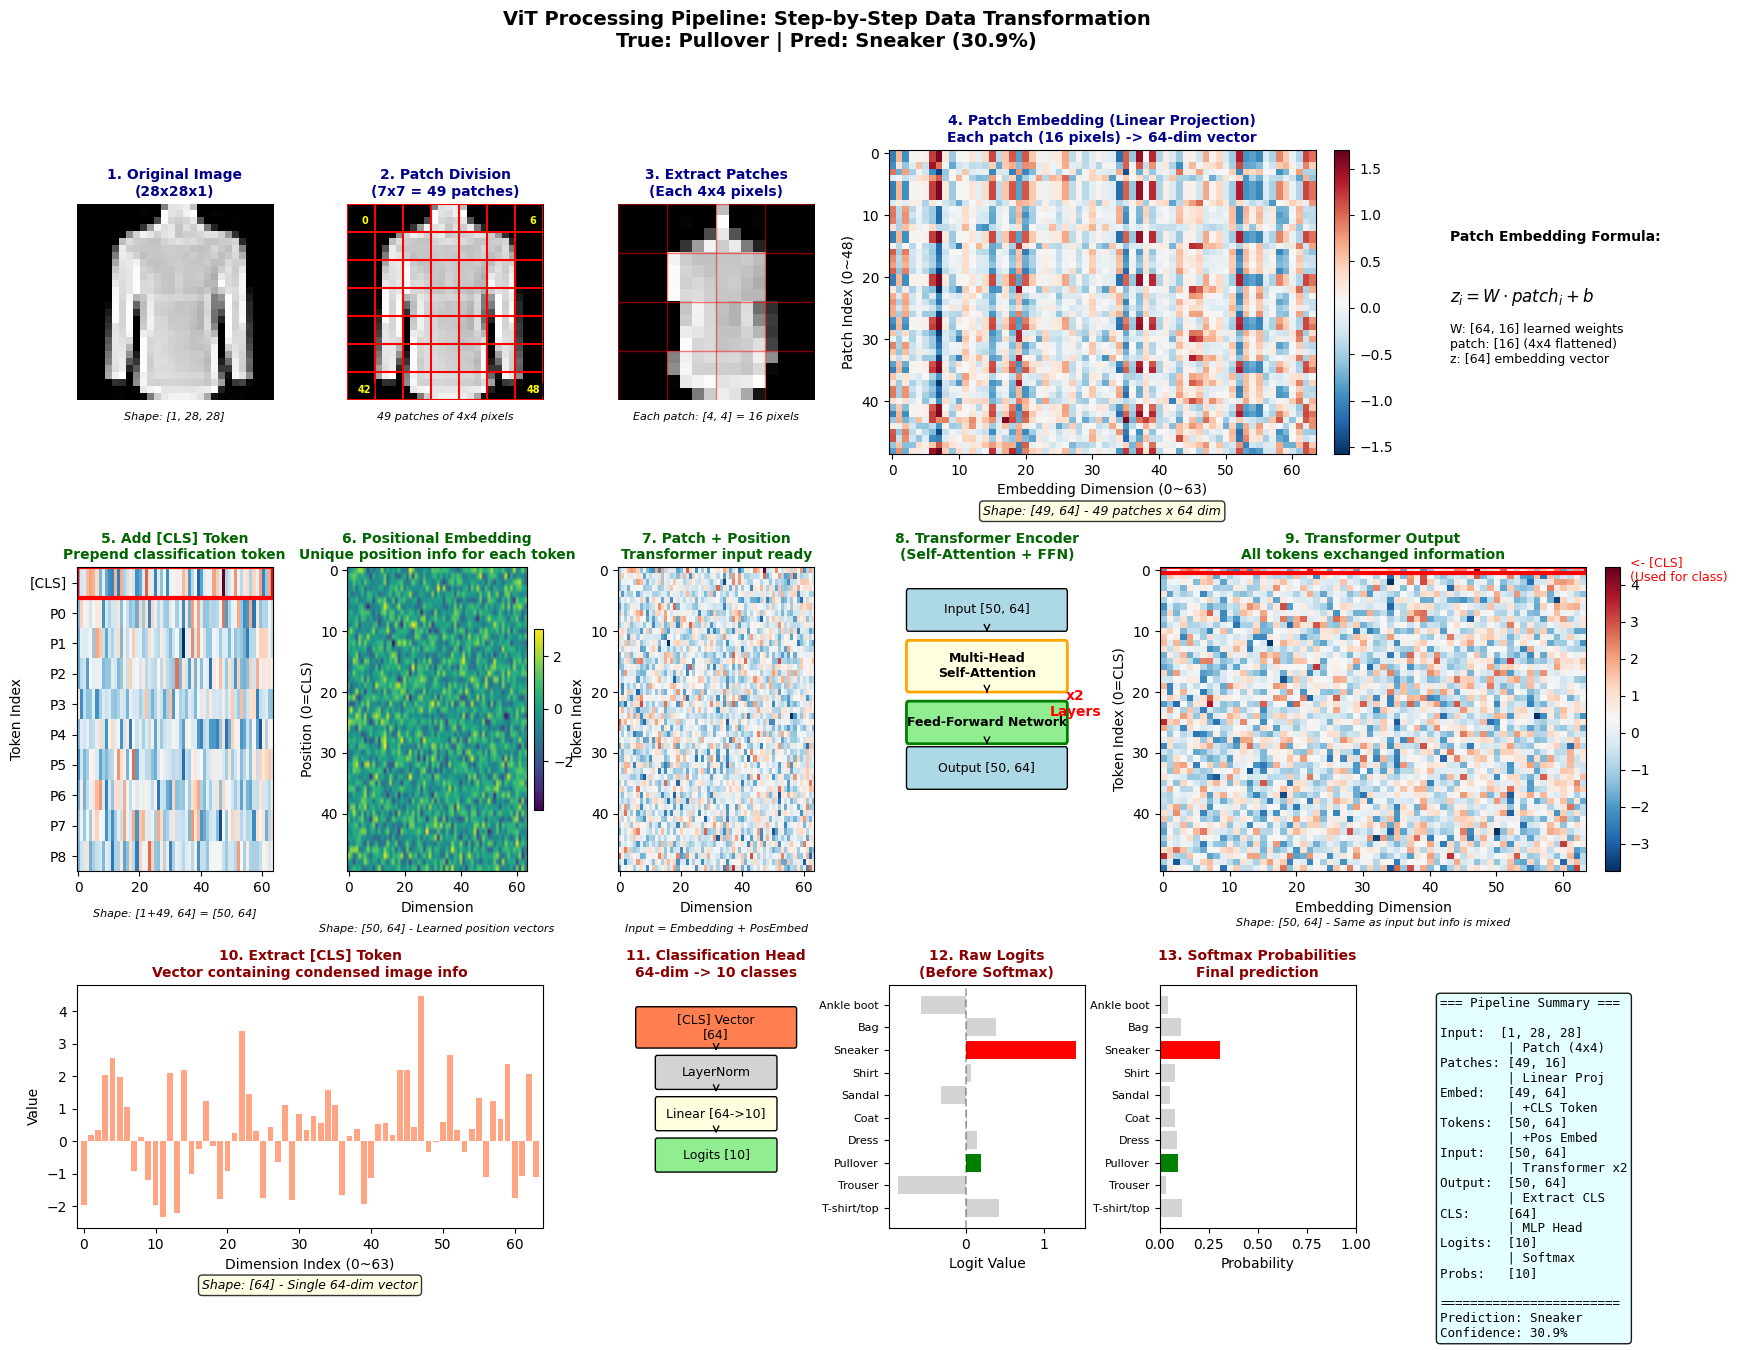


[Available Intermediate Outputs]
  after_conv: [1, 64, 7, 7]
  patch_embeddings: [1, 49, 64]
  cls_token: [1, 1, 64]
  after_cls_concat: [1, 50, 64]
  pos_embed: [1, 50, 64]
  after_pos_embed: [1, 50, 64]
  attn_weights_layer1: [1, 50, 50]
  after_attn1: [1, 50, 64]
  after_ffn1: [1, 50, 64]
  attn_weights_layer2: [1, 50, 50]
  after_attn2: [1, 50, 64]
  after_ffn2: [1, 50, 64]
  final_cls_token: [1, 64]
  logits: [1, 10]

Generating Positional Embedding Similarity Visualization...



/tmp/ipython-input-4211327083.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to ./vit_pos_embed_similarity.png


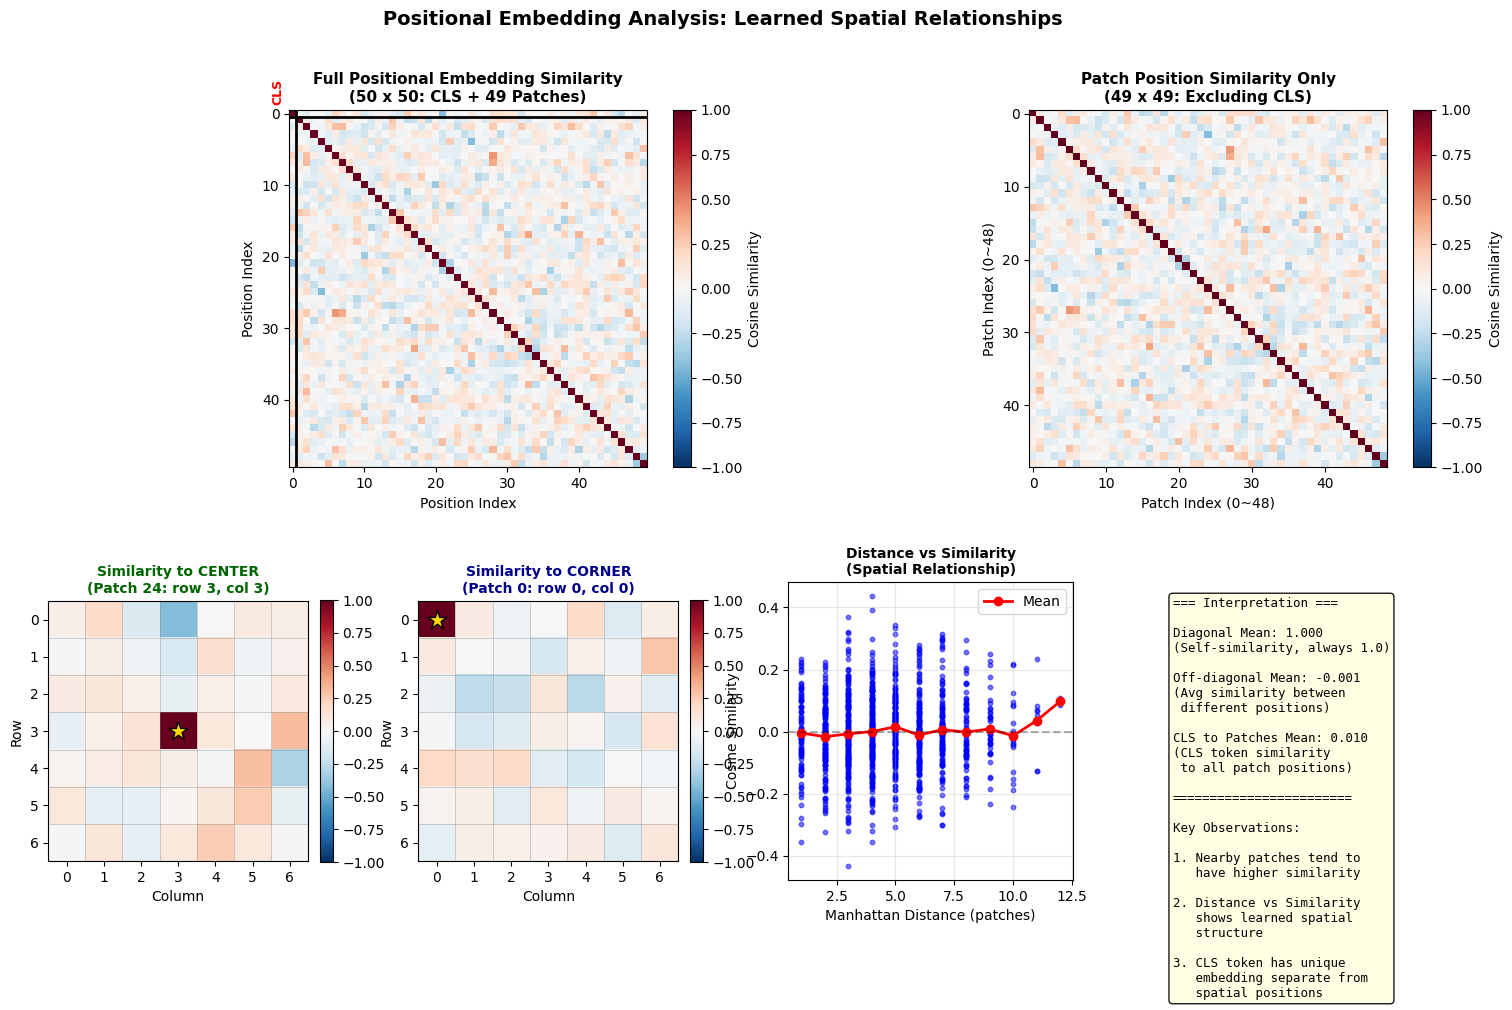


Positional Embedding Analysis Complete!
  Full similarity matrix shape: (50, 50)
  Patch similarity matrix shape: (49, 49)


In [ ]:
# ==========================================
# 4. Positional Embedding Cosine Similarity Visualization
# ==========================================
def visualize_pos_embed_similarity(model, save_path=None):
    """
    Visualize the cosine similarity between positional embeddings.
    This shows how the model learns spatial relationships between positions.
    """
    ViT_model.eval()

    # Extract positional embedding (50, 64)
    pos_embed = ViT_model.pos_embed.squeeze().detach().cpu()  # (50, 64)

    # Compute cosine similarity matrix (50, 50)
    # Normalize each position vector
    pos_embed_norm = pos_embed / pos_embed.norm(dim=1, keepdim=True)
    cos_sim_matrix = torch.mm(pos_embed_norm, pos_embed_norm.t()).numpy()  # (50, 50)

    # Separate CLS and patch embeddings
    cls_embed = pos_embed[0:1]  # (1, 64)
    patch_embed = pos_embed[1:]  # (49, 64)

    # Compute patch-only similarity (49, 49)
    patch_norm = patch_embed / patch_embed.norm(dim=1, keepdim=True)
    patch_sim_matrix = torch.mm(patch_norm, patch_norm.t()).numpy()

    # Reshape to 7x7 grid for spatial visualization
    # For each position, show similarity to center position (24)
    center_idx = 24  # Center of 7x7 grid
    center_similarity = patch_sim_matrix[center_idx].reshape(7, 7)

    # Corner position (0) similarity
    corner_similarity = patch_sim_matrix[0].reshape(7, 7)

    # -------------------------------------------------
    # Create Figure
    # -------------------------------------------------
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle("Positional Embedding Analysis: Learned Spatial Relationships",
                 fontsize=14, fontweight='bold')

    gs = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1], hspace=0.35, wspace=0.3)

    # =============================================
    # Row 1: Full similarity matrices
    # =============================================

    # [1-1] Full 50x50 similarity matrix
    ax1 = fig.add_subplot(gs[0, 0:2])
    im1 = ax1.imshow(cos_sim_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    ax1.set_title("Full Positional Embedding Similarity\n(50 x 50: CLS + 49 Patches)",
                  fontsize=11, fontweight='bold')
    ax1.set_xlabel("Position Index")
    ax1.set_ylabel("Position Index")

    # Add lines to separate CLS from patches
    ax1.axhline(y=0.5, color='black', linewidth=2)
    ax1.axvline(x=0.5, color='black', linewidth=2)
    ax1.text(-3, -3, "CLS", fontsize=9, va='center', fontweight='bold', color='red', rotation=90)

    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Cosine Similarity')

    # [1-2] Patch-only similarity (49x49)
    ax2 = fig.add_subplot(gs[0, 2:4])
    im2 = ax2.imshow(patch_sim_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    ax2.set_title("Patch Position Similarity Only\n(49 x 49: Excluding CLS)",
                  fontsize=11, fontweight='bold')
    ax2.set_xlabel("Patch Index (0~48)")
    ax2.set_ylabel("Patch Index (0~48)")

    # Highlight diagonal pattern
    ax2.plot([0, 48], [0, 48], 'k--', alpha=0.3, linewidth=1)

    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Cosine Similarity')

    # =============================================
    # Row 2: Spatial similarity maps
    # =============================================

    # [2-1] Similarity from CENTER position
    ax3 = fig.add_subplot(gs[1, 0])
    im3 = ax3.imshow(center_similarity, cmap='RdBu_r', vmin=-1, vmax=1)
    ax3.set_title(f"Similarity to CENTER\n(Patch {center_idx}: row 3, col 3)",
                  fontsize=10, fontweight='bold', color='darkgreen')

    # Mark center position
    ax3.scatter([3], [3], marker='*', s=200, c='gold', edgecolors='black', linewidths=1, zorder=5)

    # Add grid
    for i in range(8):
        ax3.axhline(y=i-0.5, color='gray', linewidth=0.5, alpha=0.5)
        ax3.axvline(x=i-0.5, color='gray', linewidth=0.5, alpha=0.5)

    ax3.set_xticks(range(7))
    ax3.set_yticks(range(7))
    ax3.set_xlabel("Column")
    ax3.set_ylabel("Row")
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    # [2-2] Similarity from CORNER position
    ax4 = fig.add_subplot(gs[1, 1])
    im4 = ax4.imshow(corner_similarity, cmap='RdBu_r', vmin=-1, vmax=1)
    ax4.set_title(f"Similarity to CORNER\n(Patch 0: row 0, col 0)",
                  fontsize=10, fontweight='bold', color='darkblue')

    # Mark corner position
    ax4.scatter([0], [0], marker='*', s=200, c='gold', edgecolors='black', linewidths=1, zorder=5)

    for i in range(8):
        ax4.axhline(y=i-0.5, color='gray', linewidth=0.5, alpha=0.5)
        ax4.axvline(x=i-0.5, color='gray', linewidth=0.5, alpha=0.5)

    ax4.set_xticks(range(7))
    ax4.set_yticks(range(7))
    ax4.set_xlabel("Column")
    ax4.set_ylabel("Row")
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

    # [2-3] Distance vs Similarity analysis
    ax5 = fig.add_subplot(gs[1, 2])

    # Calculate Manhattan distance and similarity for all pairs
    distances = []
    similarities = []
    for i in range(49):
        for j in range(49):
            if i != j:
                row_i, col_i = i // 7, i % 7
                row_j, col_j = j // 7, j % 7
                dist = abs(row_i - row_j) + abs(col_i - col_j)  # Manhattan distance
                sim = patch_sim_matrix[i, j]
                distances.append(dist)
                similarities.append(sim)

    ax5.scatter(distances, similarities, alpha=0.3, s=10, c='blue')

    # Add trend line (mean similarity per distance)
    unique_dists = sorted(set(distances))
    mean_sims = [np.mean([s for d, s in zip(distances, similarities) if d == ud]) for ud in unique_dists]
    ax5.plot(unique_dists, mean_sims, 'r-', linewidth=2, marker='o', markersize=6, label='Mean')

    ax5.set_title("Distance vs Similarity\n(Spatial Relationship)", fontsize=10, fontweight='bold')
    ax5.set_xlabel("Manhattan Distance (patches)")
    ax5.set_ylabel("Cosine Similarity")
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    ax5.axhline(y=0, color='black', linestyle='--', alpha=0.3)

    # [2-4] Interpretation text
    ax6 = fig.add_subplot(gs[1, 3])
    ax6.axis('off')

    # Calculate some statistics
    diag_mean = np.mean(np.diag(patch_sim_matrix))
    off_diag = patch_sim_matrix[~np.eye(49, dtype=bool)]
    off_diag_mean = np.mean(off_diag)

    # CLS similarity to patches
    cls_to_patches = cos_sim_matrix[0, 1:]
    cls_mean_sim = np.mean(cls_to_patches)

    interpretation = (
        "=== Interpretation ===\n\n"
        f"Diagonal Mean: {diag_mean:.3f}\n"
        f"(Self-similarity, always 1.0)\n\n"
        f"Off-diagonal Mean: {off_diag_mean:.3f}\n"
        f"(Avg similarity between\n different positions)\n\n"
        f"CLS to Patches Mean: {cls_mean_sim:.3f}\n"
        f"(CLS token similarity\n to all patch positions)\n\n"
        "========================\n\n"
        "Key Observations:\n\n"
        "1. Nearby patches tend to\n"
        "   have higher similarity\n\n"
        "2. Distance vs Similarity\n"
        "   shows learned spatial\n"
        "   structure\n\n"
        "3. CLS token has unique\n"
        "   embedding separate from\n"
        "   spatial positions"
    )
    ax6.text(0.05, 0.95, interpretation, transform=ax6.transAxes,
             fontsize=9, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"Saved to {save_path}")

    plt.show()

    return cos_sim_matrix, patch_sim_matrix


# ==========================================
# 5. Pipeline Visualization Function (Original)
# ==========================================
def visualize_vit_pipeline(model, sample_image, true_label, save_path=None):
    """
    Visualize the entire ViT processing pipeline step by step
    """
    ViT_model.eval()
    with torch.no_grad():
        img_gpu = sample_image.unsqueeze(0).to(device)
        logits, intermediates = ViT_model(img_gpu, return_intermediates=True)

        probs = torch.nn.functional.softmax(logits, dim=1)
        pred_label = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_label].item()

    # Move to CPU
    img_np = sample_image.squeeze().cpu().numpy()

    # Intermediate results
    patch_embed = intermediates['patch_embeddings'].squeeze().cpu().numpy()
    pos_embed = intermediates['pos_embed'].squeeze().cpu().numpy()
    after_pos = intermediates['after_pos_embed'].squeeze().cpu().numpy()
    after_transformer = intermediates['after_ffn2'].squeeze().cpu().numpy()
    final_cls = intermediates['final_cls_token'].squeeze().cpu().numpy()
    logits_np = intermediates['logits'].squeeze().cpu().numpy()
    probs_np = probs.cpu().squeeze().numpy()

    # Create Figure
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f"ViT Processing Pipeline: Step-by-Step Data Transformation\n"
                 f"True: {classes[true_label]} | Pred: {classes[pred_label]} ({confidence*100:.1f}%)",
                 fontsize=14, fontweight='bold')

    gs = gridspec.GridSpec(3, 6, height_ratios=[1.5, 1.5, 1.2], hspace=0.4, wspace=0.38)

    # =============================================
    # Row 1: Image -> Patch -> Embedding
    # =============================================

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(img_np, cmap='gray')
    ax1.set_title("1. Original Image\n(28x28x1)", fontsize=10, fontweight='bold', color='darkblue')
    ax1.axis('off')
    ax1.text(0.5, -0.1, "Shape: [1, 28, 28]", transform=ax1.transAxes,
             ha='center', fontsize=8, style='italic')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(img_np, cmap='gray')
    ax2.set_title("2. Patch Division\n(7x7 = 49 patches)", fontsize=10, fontweight='bold', color='darkblue')
    for i in range(8):
        ax2.axhline(y=i*4-0.5, color='red', linewidth=1.5)
        ax2.axvline(x=i*4-0.5, color='red', linewidth=1.5)
    for idx in [0, 6, 42, 48]:
        row, col = idx // 7, idx % 7
        ax2.text(col*4+2, row*4+2, str(idx), color='yellow', fontsize=7,
                ha='center', va='center', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    ax2.axis('off')
    ax2.text(0.5, -0.1, "49 patches of 4x4 pixels", transform=ax2.transAxes,
             ha='center', fontsize=8, style='italic')

    ax3 = fig.add_subplot(gs[0, 2])
    sample_indices = [0, 2, 4, 6, 14, 16, 18, 20, 28, 30, 32, 34, 42, 44, 46, 48]
    patch_grid = np.zeros((16, 16))
    for i, idx in enumerate(sample_indices):
        row_in_grid = i // 4
        col_in_grid = i % 4
        patch_row = idx // 7
        patch_col = idx % 7
        patch = img_np[patch_row*4:(patch_row+1)*4, patch_col*4:(patch_col+1)*4]
        patch_grid[row_in_grid*4:(row_in_grid+1)*4, col_in_grid*4:(col_in_grid+1)*4] = patch

    ax3.imshow(patch_grid, cmap='gray')
    ax3.set_title("3. Extract Patches\n(Each 4x4 pixels)", fontsize=10, fontweight='bold', color='darkblue')
    for i in range(4):
        ax3.axhline(y=i*4-0.5, color='red', linewidth=1, alpha=0.5)
        ax3.axvline(x=i*4-0.5, color='red', linewidth=1, alpha=0.5)
    ax3.axis('off')
    ax3.text(0.5, -0.1, "Each patch: [4, 4] = 16 pixels", transform=ax3.transAxes,
             ha='center', fontsize=8, style='italic')

    ax4 = fig.add_subplot(gs[0, 3:5])
    im4 = ax4.imshow(patch_embed, aspect='auto', cmap='RdBu_r', interpolation='nearest')
    ax4.set_title("4. Patch Embedding (Linear Projection)\nEach patch (16 pixels) -> 64-dim vector",
                  fontsize=10, fontweight='bold', color='darkblue')
    ax4.set_ylabel("Patch Index (0~48)")
    ax4.set_xlabel("Embedding Dimension (0~63)")
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
    ax4.text(0.5, -0.20, "Shape: [49, 64] - 49 patches x 64 dim", transform=ax4.transAxes,
             ha='center', fontsize=9, style='italic',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    ax5 = fig.add_subplot(gs[0, 5])
    ax5.axis('off')
    ax5.text(0.1, 0.7, "Patch Embedding Formula:", fontsize=10, fontweight='bold')
    ax5.text(0.1, 0.5, r"$z_i = W \cdot patch_i + b$", fontsize=12)
    ax5.text(0.1, 0.3, "W: [64, 16] learned weights\n"
                       "patch: [16] (4x4 flattened)\n"
                       "z: [64] embedding vector", fontsize=9)

    # =============================================
    # Row 2: CLS Token -> Positional Embedding -> Transformer
    # =============================================

    ax6 = fig.add_subplot(gs[1, 0])
    cls_and_patches = after_pos[:10, :]
    im6 = ax6.imshow(cls_and_patches, aspect='auto', cmap='RdBu_r')
    ax6.set_title("5. Add [CLS] Token\nPrepend classification token", fontsize=10, fontweight='bold', color='darkgreen')
    ax6.set_ylabel("Token Index")
    ax6.set_yticks(range(10))
    ax6.set_yticklabels(['[CLS]'] + [f'P{i}' for i in range(9)])
    rect = Rectangle((-0.5, -0.5), 64, 1, fill=False, edgecolor='red', linewidth=3)
    ax6.add_patch(rect)
    ax6.text(0.5, -0.15, "Shape: [1+49, 64] = [50, 64]", transform=ax6.transAxes,
             ha='center', fontsize=8, style='italic')

    ax7 = fig.add_subplot(gs[1, 1])
    im7 = ax7.imshow(pos_embed, aspect='auto', cmap='viridis')
    ax7.set_title("6. Positional Embedding\nUnique position info for each token", fontsize=10, fontweight='bold', color='darkgreen')
    ax7.set_ylabel("Position (0=CLS)")
    ax7.set_xlabel("Dimension")
    plt.colorbar(im7, ax=ax7, fraction=0.046, pad=0.04)
    ax7.text(0.5, -0.20, "Shape: [50, 64] - Learned position vectors", transform=ax7.transAxes,
             ha='center', fontsize=8, style='italic')

    ax8 = fig.add_subplot(gs[1, 2])
    im8 = ax8.imshow(after_pos, aspect='auto', cmap='RdBu_r')
    ax8.set_title("7. Patch + Position\nTransformer input ready", fontsize=10, fontweight='bold', color='darkgreen')
    ax8.set_ylabel("Token Index")
    ax8.set_xlabel("Dimension")
    ax8.text(0.5, -0.20, "Input = Embedding + PosEmbed", transform=ax8.transAxes,
             ha='center', fontsize=8, style='italic')

    ax9 = fig.add_subplot(gs[1, 3])
    ax9.axis('off')
    ax9.set_xlim(0, 10)
    ax9.set_ylim(0, 10)

    ax9.add_patch(FancyBboxPatch((1, 8), 8, 1.2, boxstyle="round,pad=0.1",
                                  facecolor='lightblue', edgecolor='black'))
    ax9.text(5, 8.6, "Input [50, 64]", ha='center', va='center', fontsize=9)

    ax9.annotate('', xy=(5, 7.8), xytext=(5, 8),
                arrowprops=dict(arrowstyle='->', color='black'))
    ax9.add_patch(FancyBboxPatch((1, 6), 8, 1.5, boxstyle="round,pad=0.1",
                                  facecolor='lightyellow', edgecolor='orange', linewidth=2))
    ax9.text(5, 6.75, "Multi-Head\nSelf-Attention", ha='center', va='center', fontsize=9, fontweight='bold')

    ax9.annotate('', xy=(5, 5.8), xytext=(5, 6),
                arrowprops=dict(arrowstyle='->', color='black'))
    ax9.add_patch(FancyBboxPatch((1, 4.3), 8, 1.2, boxstyle="round,pad=0.1",
                                  facecolor='lightgreen', edgecolor='green', linewidth=2))
    ax9.text(5, 4.9, "Feed-Forward Network", ha='center', va='center', fontsize=9, fontweight='bold')

    ax9.annotate('', xy=(5, 4.1), xytext=(5, 4.3),
                arrowprops=dict(arrowstyle='->', color='black'))
    ax9.add_patch(FancyBboxPatch((1, 2.8), 8, 1.2, boxstyle="round,pad=0.1",
                                  facecolor='lightblue', edgecolor='black'))
    ax9.text(5, 3.4, "Output [50, 64]", ha='center', va='center', fontsize=9)

    ax9.text(9.5, 5.5, "x2\nLayers", ha='center', va='center', fontsize=10, fontweight='bold', color='red')
    ax9.set_title("8. Transformer Encoder\n(Self-Attention + FFN)", fontsize=10, fontweight='bold', color='darkgreen')

    ax10 = fig.add_subplot(gs[1, 4:6])
    im10 = ax10.imshow(after_transformer, aspect='auto', cmap='RdBu_r')
    ax10.set_title("9. Transformer Output\nAll tokens exchanged information",
                   fontsize=10, fontweight='bold', color='darkgreen')
    ax10.set_ylabel("Token Index (0=CLS)")
    ax10.set_xlabel("Embedding Dimension")
    rect = Rectangle((-0.5, -0.5), 64, 1, fill=False, edgecolor='red', linewidth=3)
    ax10.add_patch(rect)
    ax10.text(70, 0, "<- [CLS]\n(Used for class)", fontsize=9, color='red', va='center')
    plt.colorbar(im10, ax=ax10, fraction=0.046, pad=0.04)
    ax10.text(0.5, -0.18, "Shape: [50, 64] - Same as input but info is mixed", transform=ax10.transAxes,
             ha='center', fontsize=8, style='italic')

    # =============================================
    # Row 3: CLS Extract -> MLP Head -> Prediction
    # =============================================

    ax11 = fig.add_subplot(gs[2, 0:2])
    ax11.bar(range(64), final_cls, color='coral', alpha=0.7)
    ax11.set_title("10. Extract [CLS] Token\nVector containing condensed image info",
                   fontsize=10, fontweight='bold', color='darkred')
    ax11.set_xlabel("Dimension Index (0~63)")
    ax11.set_ylabel("Value")
    ax11.set_xlim(-1, 64)
    ax11.text(0.5, -0.25, "Shape: [64] - Single 64-dim vector", transform=ax11.transAxes,
             ha='center', fontsize=9, style='italic',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    ax12 = fig.add_subplot(gs[2, 2])
    ax12.axis('off')
    ax12.set_xlim(0, 10)
    ax12.set_ylim(0, 10)

    ax12.add_patch(FancyBboxPatch((1, 7.5), 8, 1.5, boxstyle="round,pad=0.1",
                                   facecolor='coral', edgecolor='black'))
    ax12.text(5, 8.25, "[CLS] Vector\n[64]", ha='center', va='center', fontsize=9)

    ax12.annotate('', xy=(5, 7.3), xytext=(5, 7.5),
                 arrowprops=dict(arrowstyle='->', color='black'))
    ax12.add_patch(FancyBboxPatch((2, 5.8), 6, 1.2, boxstyle="round,pad=0.1",
                                   facecolor='lightgray', edgecolor='black'))
    ax12.text(5, 6.4, "LayerNorm", ha='center', va='center', fontsize=9)

    ax12.annotate('', xy=(5, 5.6), xytext=(5, 5.8),
                 arrowprops=dict(arrowstyle='->', color='black'))
    ax12.add_patch(FancyBboxPatch((2, 4.1), 6, 1.2, boxstyle="round,pad=0.1",
                                   facecolor='lightyellow', edgecolor='black'))
    ax12.text(5, 4.7, "Linear [64->10]", ha='center', va='center', fontsize=9)

    ax12.annotate('', xy=(5, 3.9), xytext=(5, 4.1),
                 arrowprops=dict(arrowstyle='->', color='black'))
    ax12.add_patch(FancyBboxPatch((2, 2.4), 6, 1.2, boxstyle="round,pad=0.1",
                                   facecolor='lightgreen', edgecolor='black'))
    ax12.text(5, 3, "Logits [10]", ha='center', va='center', fontsize=9)

    ax12.set_title("11. Classification Head\n64-dim -> 10 classes", fontsize=10, fontweight='bold', color='darkred')

    ax13 = fig.add_subplot(gs[2, 3])
    colors = ['lightgray'] * 10
    colors[pred_label] = 'red'
    if true_label != pred_label:
        colors[true_label] = 'green'
    ax13.barh(range(10), logits_np, color=colors)
    ax13.set_yticks(range(10))
    ax13.set_yticklabels(classes, fontsize=8)
    ax13.set_title("12. Raw Logits\n(Before Softmax)", fontsize=10, fontweight='bold', color='darkred')
    ax13.set_xlabel("Logit Value")
    ax13.axvline(x=0, color='black', linestyle='--', alpha=0.3)

    ax14 = fig.add_subplot(gs[2, 4])
    ax14.barh(range(10), probs_np, color=colors)
    ax14.set_yticks(range(10))
    ax14.set_yticklabels(classes, fontsize=8)
    ax14.set_title("13. Softmax Probabilities\nFinal prediction", fontsize=10, fontweight='bold', color='darkred')
    ax14.set_xlabel("Probability")
    ax14.set_xlim(0, 1.0)

    ax15 = fig.add_subplot(gs[2, 5])
    ax15.axis('off')

    summary = (
        "=== Pipeline Summary ===\n\n"
        f"Input:  [1, 28, 28]\n"
        f"         | Patch (4x4)\n"
        f"Patches: [49, 16]\n"
        f"         | Linear Proj\n"
        f"Embed:   [49, 64]\n"
        f"         | +CLS Token\n"
        f"Tokens:  [50, 64]\n"
        f"         | +Pos Embed\n"
        f"Input:   [50, 64]\n"
        f"         | Transformer x2\n"
        f"Output:  [50, 64]\n"
        f"         | Extract CLS\n"
        f"CLS:     [64]\n"
        f"         | MLP Head\n"
        f"Logits:  [10]\n"
        f"         | Softmax\n"
        f"Probs:   [10]\n\n"
        f"========================\n"
        f"Prediction: {classes[pred_label]}\n"
        f"Confidence: {confidence*100:.1f}%"
    )
    ax15.text(0.05, 0.95, summary, transform=ax15.transAxes,
              fontsize=9, verticalalignment='top', fontfamily='monospace',
              bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.9))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"Saved to {save_path}")

    plt.show()

    return intermediates


# ==========================================
# 6. Run
# ==========================================
print("="*60)
print("Generating ViT Pipeline Visualization...")
print("="*60 + "\n")

# Get test image
dataiter = iter(testloader)
images, labels = next(dataiter)

# 1. Pipeline visualization
intermediates = visualize_vit_pipeline(
    ViT_model, images[0], labels[0].item(),
    save_path='./vit_pipeline_result.png'
)

print("\n[Available Intermediate Outputs]")
for key, value in intermediates.items():
    if isinstance(value, torch.Tensor):
        print(f"  {key}: {list(value.shape)}")

# 2. Positional Embedding Similarity visualization
print("\n" + "="*60)
print("Generating Positional Embedding Similarity Visualization...")
print("="*60 + "\n")

cos_sim_full, cos_sim_patches = visualize_pos_embed_similarity(
    ViT_model,
    save_path='./vit_pos_embed_similarity.png'
)

print("\nPositional Embedding Analysis Complete!")
print(f"  Full similarity matrix shape: {cos_sim_full.shape}")
print(f"  Patch similarity matrix shape: {cos_sim_patches.shape}")

flow도 탐구탐구 진행

Model Parameters: 11,792,640


Epoch 1/15 [Train]: 100%|██████████| 469/469 [00:17<00:00, 26.80it/s, loss=-1.27e+3]


Epoch 1 | Train Loss (NLL): -985.2721


Epoch 2/15 [Train]: 100%|██████████| 469/469 [00:16<00:00, 28.85it/s, loss=-1.4e+3]


Epoch 2 | Train Loss (NLL): -1299.9681


...

Epoch 3 | Train Loss (NLL): -1385.6437


Epoch 4/15 [Train]: 100%|██████████| 469/469 [00:16<00:00, 29.11it/s, loss=-1.45e+3]


Epoch 4 | Train Loss (NLL): -1436.9206


Epoch 5/15 [Train]: 100%|██████████| 469/469 [00:16<00:00, 28.53it/s, loss=-1.5e+3]


Epoch 5 | Train Loss (NLL): -1472.0270


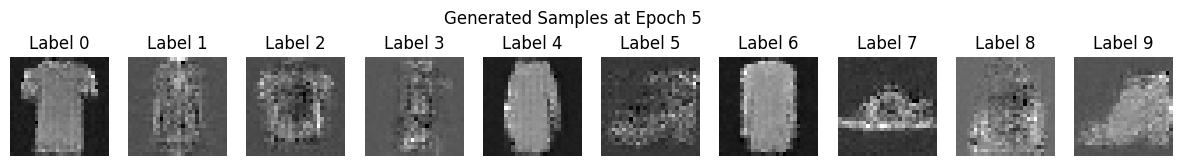

[Eval Classification]: 100%|██████████| 79/79 [00:05<00:00, 14.88it/s, acc=71.54%]


Epoch 5 | Test Accuracy: 71.54%
--> Best Model Saved!


Epoch 6/15 [Train]: 100%|██████████| 469/469 [00:16<00:00, 28.11it/s, loss=-1.56e+3]


Epoch 6 | Train Loss (NLL): -1498.6365


Epoch 7/15 [Train]: 100%|██████████| 469/469 [00:15<00:00, 29.43it/s, loss=-1.51e+3]


...

Epoch 8 | Train Loss (NLL): -1537.0442


Epoch 9/15 [Train]: 100%|██████████| 469/469 [00:16<00:00, 28.16it/s, loss=-1.52e+3]


Epoch 9 | Train Loss (NLL): -1551.6217


Epoch 10/15 [Train]: 100%|██████████| 469/469 [00:16<00:00, 29.14it/s, loss=-1.53e+3]


Epoch 10 | Train Loss (NLL): -1564.2948


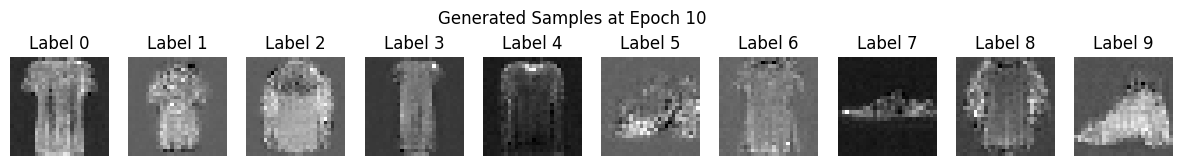

[Eval Classification]: 100%|██████████| 79/79 [00:04<00:00, 16.53it/s, acc=71.99%]


Epoch 10 | Test Accuracy: 71.99%
--> Best Model Saved!


Epoch 11/15 [Train]: 100%|██████████| 469/469 [00:16<00:00, 28.22it/s, loss=-1.51e+3]


Epoch 11 | Train Loss (NLL): -1575.7512


Epoch 12/15 [Train]: 100%|██████████| 469/469 [00:16<00:00, 28.93it/s, loss=-1.64e+3]


...

Epoch 13 | Train Loss (NLL): -1594.7124


Epoch 14/15 [Train]: 100%|██████████| 469/469 [00:17<00:00, 26.88it/s, loss=-1.62e+3]


Epoch 14 | Train Loss (NLL): -1603.7166


Epoch 15/15 [Train]: 100%|██████████| 469/469 [00:16<00:00, 28.65it/s, loss=-1.59e+3]


Epoch 15 | Train Loss (NLL): -1610.5499


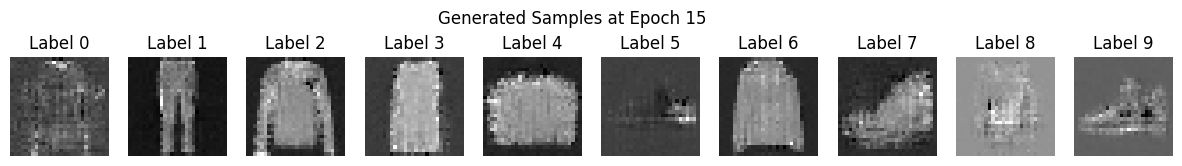

[Eval Classification]: 100%|██████████| 79/79 [00:04<00:00, 16.62it/s, acc=70.96%]


Epoch 15 | Test Accuracy: 70.96%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# ==========================================
# 1. Configuration (설정 관리)
# ==========================================
class Config:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 128
    LR = 1e-3
    EPOCHS = 15
    LATENT_DIM = 784  # 28*28
    HIDDEN_DIM = 512
    NUM_LAYERS = 8    # 층을 조금 더 깊게 쌓음
    NUM_CLASSES = 10
    DATA_ROOT = './data'

cfg = Config()

# ==========================================
# 2. Data Loader
# ==========================================
def get_dataloaders():
    transform = transforms.Compose([
        transforms.ToTensor(),
        # Dequantization: 이산적인 픽셀 값(0~255)을 연속적인 분포로 변환
        transforms.Lambda(lambda x: x + torch.rand_like(x) / 256.0),
        transforms.Lambda(lambda x: x.view(-1)) # Flatten
    ])

    train_dataset = torchvision.datasets.FashionMNIST(root=cfg.DATA_ROOT, train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.FashionMNIST(root=cfg.DATA_ROOT, train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, test_loader

# ==========================================
# 3. Model Architecture (RealNVP)
# ==========================================
class AffineCoupling(nn.Module):
    def __init__(self, input_dim, hidden_dim, mask, num_classes):
        super(AffineCoupling, self).__init__()
        self.register_buffer('mask', mask) # 학습되지 않는 상수 텐서로 등록

        in_channels = input_dim + num_classes

        # Scale(s)과 Translation(t) 예측 네트워크
        # 안정성을 위해 Batch Normalization 추가 및 초기화 고려 가능 (여기선 기본 유지)
        self.net = nn.Sequential(
            nn.Linear(in_channels, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim * 2) # [s, t]
        )

    def forward(self, x, y_onehot):
        x_masked = x * self.mask
        net_input = torch.cat([x_masked, y_onehot], dim=1)

        out = self.net(net_input)
        s, t = out.chunk(2, dim=1)

        # 수치 안정성을 위한 Scaling (tanh 사용)
        s = torch.tanh(s)

        # 마스킹 적용 (변하지 않는 부분은 0으로)
        s = s * (1 - self.mask)
        t = t * (1 - self.mask)

        # Affine 변환: z = x * exp(s) + t
        # (마스킹 된 부분은 s=0, t=0이므로 z = x * 1 + 0 = x 그대로 유지됨)
        z = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)

        log_det = torch.sum(s, dim=1)
        return z, log_det

    def inverse(self, z, y_onehot):
        z_masked = z * self.mask
        net_input = torch.cat([z_masked, y_onehot], dim=1)

        out = self.net(net_input)
        s, t = out.chunk(2, dim=1)
        s = torch.tanh(s)

        s = s * (1 - self.mask)
        t = t * (1 - self.mask)

        # 역변환: x = (z - t) * exp(-s)
        x = z_masked + (1 - self.mask) * ((z - t) * torch.exp(-s))
        return x

class ConditionalRealNVP(nn.Module):
    def __init__(self, config):
        super(ConditionalRealNVP, self).__init__()
        self.layers = nn.ModuleList()
        self.input_dim = config.LATENT_DIM
        self.num_classes = config.NUM_CLASSES

        # Prior Distribution: N(0, I)
        self.register_buffer('prior_mean', torch.zeros(1))
        self.register_buffer('prior_var', torch.ones(1))

        # 마스크 생성 (Checkerboard pattern for 1D)
        mask_even = torch.tensor([1 if i % 2 == 0 else 0 for i in range(self.input_dim)], dtype=torch.float32)
        mask_odd = 1 - mask_even

        for i in range(config.NUM_LAYERS):
            mask = mask_even if i % 2 == 0 else mask_odd
            self.layers.append(AffineCoupling(self.input_dim, config.HIDDEN_DIM, mask, self.num_classes))

    def prior_log_prob(self, z):
        # Gaussian Log Likelihood
        return -0.5 * (torch.log(2 * torch.tensor(np.pi)) + torch.log(self.prior_var) + (z - self.prior_mean) ** 2 / self.prior_var).sum(dim=1)

    def forward(self, x, y):
        """ Inference: x -> z (Latent Space) """
        y_onehot = torch.nn.functional.one_hot(y, num_classes=self.num_classes).float()
        log_det_sum = 0
        z = x

        for layer in self.layers:
            z, log_det = layer(z, y_onehot)
            log_det_sum += log_det

        return z, log_det_sum

    def inverse(self, z, y):
        """ Generation: z -> x (Data Space) """
        y_onehot = torch.nn.functional.one_hot(y, num_classes=self.num_classes).float()
        x = z
        # 역전파는 레이어의 역순으로 진행
        for layer in reversed(self.layers):
            x = layer.inverse(x, y_onehot)
        return x

    def sample(self, num_samples, y):
        """ 특정 클래스 y에 대해 이미지 생성 """
        z = torch.randn(num_samples, self.input_dim).to(x.device if 'x' in locals() else cfg.DEVICE)
        with torch.no_grad():
            x_gen = self.inverse(z, y)
        return x_gen

# ==========================================
# 4. Trainer Class (학습 및 평가 관리)
# ==========================================
class FlowTrainer:
    def __init__(self, model, train_loader, test_loader, config):
        self.model = model.to(config.DEVICE)
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.cfg = config
        self.optimizer = optim.Adam(model.parameters(), lr=config.LR)

    def loss_function(self, x, y):
        z, log_det_sum = self.model(x, y)
        log_prob_z = self.model.prior_log_prob(z)
        # Maximize Log-Likelihood -> Minimize Negative Log-Likelihood
        loss = -(log_prob_z + log_det_sum).mean()
        return loss

    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0
        pbar = tqdm(self.train_loader, desc=f"Epoch {epoch}/{self.cfg.EPOCHS} [Train]")

        for x, y in pbar:
            x, y = x.to(self.cfg.DEVICE), y.to(self.cfg.DEVICE)

            loss = self.loss_function(x, y)

            self.optimizer.zero_grad()
            loss.backward()

            # Gradient Clipping (Flow 모델 학습 안정화)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            self.optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})

        return total_loss / len(self.train_loader)

    def evaluate_classification(self):
        """ Flow 모델을 이용한 Classification Accuracy 측정 """
        self.model.eval()
        correct = 0
        total = 0

        # 추론 속도를 위해 테스트셋 일부만 사용할 수도 있음
        pbar = tqdm(self.test_loader, desc="[Eval Classification]")

        with torch.no_grad():
            for x, y_true in pbar:
                x, y_true = x.to(self.cfg.DEVICE), y_true.to(self.cfg.DEVICE)
                batch_size = x.size(0)

                # [Batch, 10] 크기의 Log-Likelihood 테이블
                log_probs = torch.zeros(batch_size, self.cfg.NUM_CLASSES).to(self.cfg.DEVICE)

                # 모든 클래스(0~9)를 가정하여 Likelihood 계산 (Generative Classifier)
                # P(y|x) ∝ P(x|y) * P(y)
                for class_idx in range(self.cfg.NUM_CLASSES):
                    y_candidate = torch.full((batch_size,), class_idx, dtype=torch.long).to(self.cfg.DEVICE)

                    z, log_det_sum = self.model(x, y_candidate)
                    log_prob_z = self.model.prior_log_prob(z)
                    log_likelihood = log_prob_z + log_det_sum

                    log_probs[:, class_idx] = log_likelihood

                pred = torch.argmax(log_probs, dim=1)
                correct += (pred == y_true).sum().item()
                total += batch_size

                pbar.set_postfix({'acc': f"{100 * correct / total:.2f}%"})

        return 100 * correct / total

    def visualize_generation(self, epoch):
        """ 학습 중간에 생성된 이미지를 시각화 """
        self.model.eval()
        num_samples = 10 # 각 클래스 별 1개씩
        fig, axes = plt.subplots(1, 10, figsize=(15, 2))

        for i in range(10):
            y_target = torch.tensor([i]).to(self.cfg.DEVICE)
            # Random Latent z에서 역변환
            z = torch.randn(1, self.cfg.LATENT_DIM).to(self.cfg.DEVICE)
            with torch.no_grad():
                x_gen = self.model.inverse(z, y_target)

            img = x_gen.cpu().view(28, 28).numpy()
            axes[i].imshow(img, cmap='gray')
            axes[i].axis('off')
            axes[i].set_title(f"Label {i}")

        plt.suptitle(f"Generated Samples at Epoch {epoch}")
        plt.show()

# ==========================================
# 5. Main Execution
# ==========================================
def main():
    # 1. 데이터 로드
    train_loader, test_loader = get_dataloaders()

    # 2. 모델 초기화
    model = ConditionalRealNVP(cfg)
    print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")

    # 3. Trainer 초기화
    trainer = FlowTrainer(model, train_loader, test_loader, cfg)

    # 4. 학습 루프
    best_acc = 0
    for epoch in range(1, cfg.EPOCHS + 1):
        # Train
        train_loss = trainer.train_epoch(epoch)
        print(f"Epoch {epoch} | Train Loss (NLL): {train_loss:.4f}")

        # Generation Visualization (5 에폭마다)
        if epoch % 5 == 0:
            trainer.visualize_generation(epoch)

            # Evaluate (시간이 오래 걸리므로 가끔 수행)
            acc = trainer.evaluate_classification()
            print(f"Epoch {epoch} | Test Accuracy: {acc:.2f}%")

            if acc > best_acc:
                best_acc = acc
                print("--> Best Model Saved!")
                torch.save(model.state_dict(), "best_flow_model.pth")

if __name__ == "__main__":
    main()

🏗️ 시각화 모델 초기화 중...
📥 저장된 모델(best_flow_model.pth) 로드 중...
✅ 모델 로드 완료!
🧐 분석 대상: Class 9


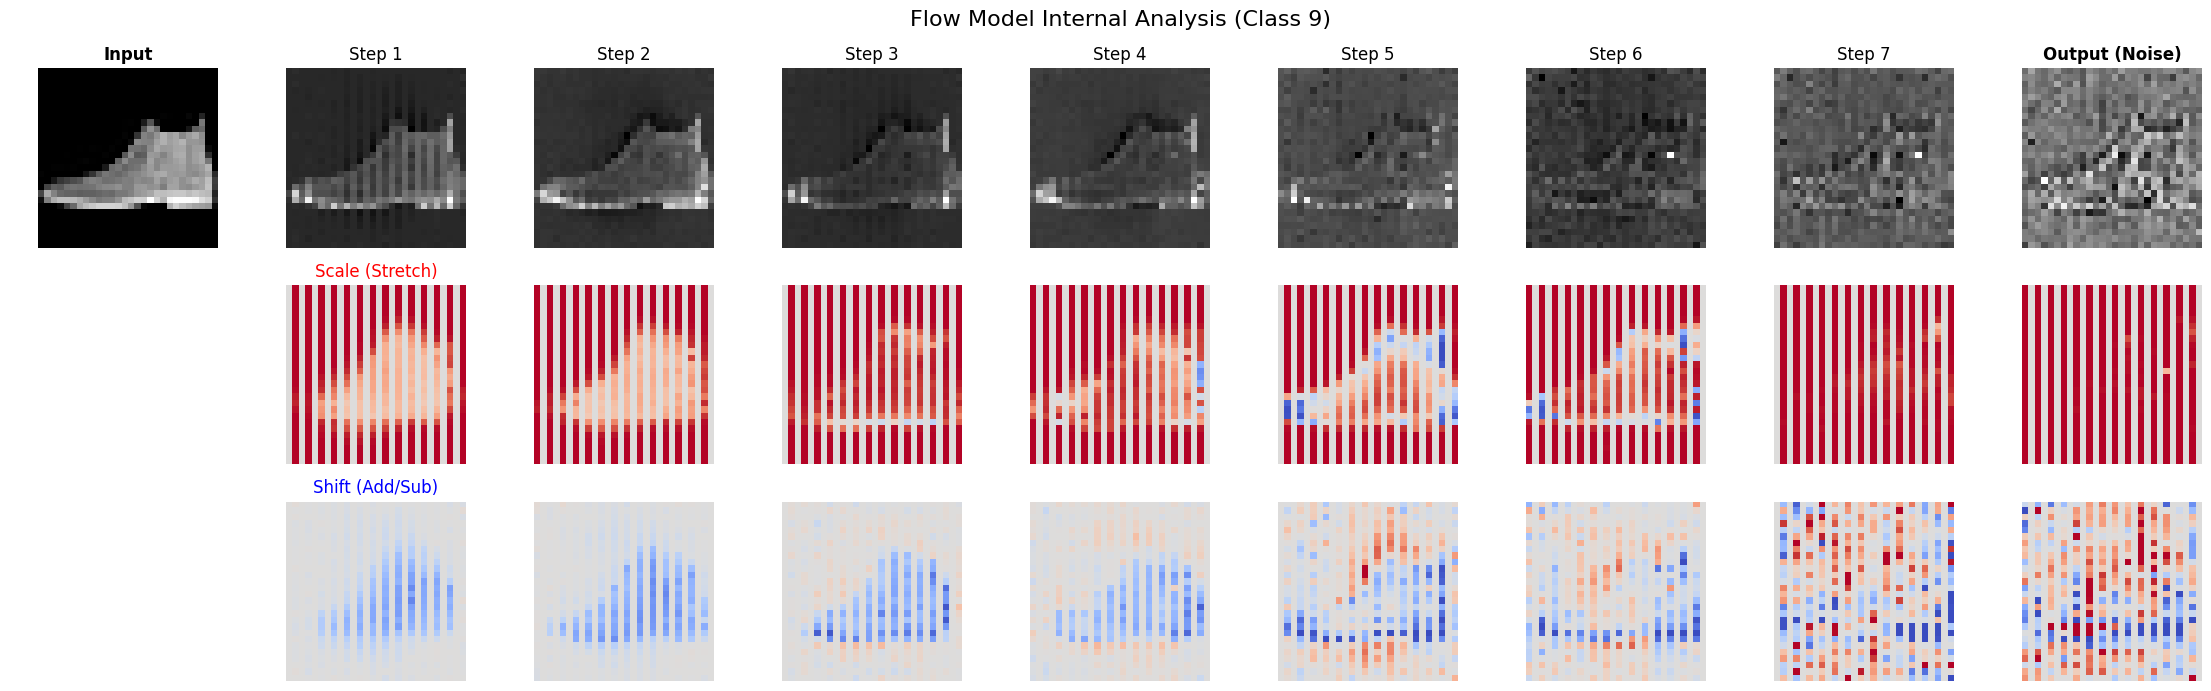

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os

# ==========================================
# 1. 설정
# ==========================================
class Config:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 128
    LATENT_DIM = 784
    HIDDEN_DIM = 512
    NUM_LAYERS = 8
    NUM_CLASSES = 10
    DATA_ROOT = './data'

cfg = Config()

# ==========================================
# 2. 데이터 로더
# ==========================================
def get_test_loader():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x + torch.rand_like(x) / 256.0),
        transforms.Lambda(lambda x: x.view(-1))
    ])
    test_dataset = torchvision.datasets.FashionMNIST(root=cfg.DATA_ROOT, train=False, download=True, transform=transform)
    return DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False)

# ==========================================
# 3. 시각화 전용 모델 클래스 (수정됨)
# ==========================================
class AffineCoupling_DeepViz(nn.Module):
    def __init__(self, input_dim, hidden_dim, mask, num_classes):
        super(AffineCoupling_DeepViz, self).__init__()
        self.register_buffer('mask', mask)
        in_channels = input_dim + num_classes

        self.net = nn.Sequential(
            nn.Linear(in_channels, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim * 2)
        )

    def forward(self, x, y_onehot):
        x_masked = x * self.mask
        net_input = torch.cat([x_masked, y_onehot], dim=1)

        out = self.net(net_input)
        s, t = out.chunk(2, dim=1)
        s = torch.tanh(s)

        s_masked = s * (1 - self.mask)
        t_masked = t * (1 - self.mask)

        z = x_masked + (1 - self.mask) * (x * torch.exp(s_masked) + t_masked)

        return z, s_masked, t_masked

class ConditionalRealNVP_DeepViz(nn.Module):
    def __init__(self, config):
        super(ConditionalRealNVP_DeepViz, self).__init__()
        self.layers = nn.ModuleList()
        self.input_dim = config.LATENT_DIM
        self.num_classes = config.NUM_CLASSES

        # [수정된 부분] 학습 모델과 구조를 맞추기 위해 버퍼 등록 추가
        self.register_buffer('prior_mean', torch.zeros(1))
        self.register_buffer('prior_var', torch.ones(1))

        mask_even = torch.tensor([1 if i % 2 == 0 else 0 for i in range(self.input_dim)], dtype=torch.float32)
        mask_odd = 1 - mask_even

        for i in range(config.NUM_LAYERS):
            mask = mask_even if i % 2 == 0 else mask_odd
            self.layers.append(AffineCoupling_DeepViz(self.input_dim, config.HIDDEN_DIM, mask, self.num_classes))

    def forward(self, x, y):
        y_onehot = torch.nn.functional.one_hot(y, num_classes=self.num_classes).float()

        viz_data = []
        z = x

        # 초기 상태 저장
        viz_data.append((z.detach().cpu(), None, None))

        for layer in self.layers:
            z, s, t = layer(z, y_onehot)
            # 단계별 데이터 수집
            viz_data.append((z.detach().cpu(), s.detach().cpu(), t.detach().cpu()))

        return viz_data

# ==========================================
# 4. 시각화 실행 함수
# ==========================================
def run_deep_viz(model_path):
    print("🏗️ 시각화 모델 초기화 중...")
    model = ConditionalRealNVP_DeepViz(cfg).to(cfg.DEVICE)

    if not os.path.exists(model_path):
        print(f"❌ 오류: '{model_path}' 파일을 찾을 수 없습니다.")
        return

    print(f"📥 저장된 모델({model_path}) 로드 중...")
    try:
        # [Tip] strict=False를 쓰면 불필요한 키 에러를 무시할 수도 있지만,
        # 여기서는 정확한 구조 일치를 위해 클래스를 수정했습니다.
        state_dict = torch.load(model_path, map_location=cfg.DEVICE)
        model.load_state_dict(state_dict)
        model.eval()
        print("✅ 모델 로드 완료!")
    except Exception as e:
        print(f"❌ 모델 로드 실패: {e}")
        return

    # 데이터 가져오기
    test_loader = get_test_loader()
    x_real, y_real = next(iter(test_loader))
    x_real = x_real[0:1].to(cfg.DEVICE)
    y_real = y_real[0:1].to(cfg.DEVICE)

    print(f"🧐 분석 대상: Class {y_real.item()}")

    # 추론
    with torch.no_grad():
        viz_data = model(x_real, y_real)

    # 그리기
    num_steps = len(viz_data)
    fig, axes = plt.subplots(nrows=3, ncols=num_steps, figsize=(2.5 * num_steps, 7))
    cmap_st = 'coolwarm'

    for i, (z, s, t) in enumerate(viz_data):
        # [Row 1] Image Z
        ax_img = axes[0][i]
        img_view = z.view(28, 28).numpy()
        ax_img.imshow(img_view, cmap='gray')
        ax_img.axis('off')
        if i == 0: ax_img.set_title("Input", fontweight='bold')
        elif i == num_steps - 1: ax_img.set_title("Output (Noise)", fontweight='bold')
        else: ax_img.set_title(f"Step {i}")

        # [Row 2] Scale Map
        ax_scale = axes[1][i]
        if s is not None:
            s_view = s.view(28, 28).numpy()
            ax_scale.imshow(s_view, cmap=cmap_st, vmin=-1, vmax=1)
            if i == 1: ax_scale.set_title("Scale (Stretch)", color='red')
        ax_scale.axis('off')

        # [Row 3] Shift Map
        ax_trans = axes[2][i]
        if t is not None:
            t_view = t.view(28, 28).numpy()
            ax_trans.imshow(t_view, cmap=cmap_st, vmin=-1, vmax=1)
            if i == 1: ax_trans.set_title("Shift (Add/Sub)", color='blue')
        ax_trans.axis('off')

    plt.suptitle(f"Flow Model Internal Analysis (Class {y_real.item()})", fontsize=16)
    plt.tight_layout()
    plt.show()

# ==========================================
# 실행
# ==========================================
if __name__ == "__main__":
    MODEL_FILENAME = "best_flow_model.pth"
    run_deep_viz(MODEL_FILENAME)

📥 모델 로드 중...
🎨 파이프라인 시각화 생성 중... (Class 9)


/tmp/ipython-input-636969232.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved visualization to flow_pipeline_result.png


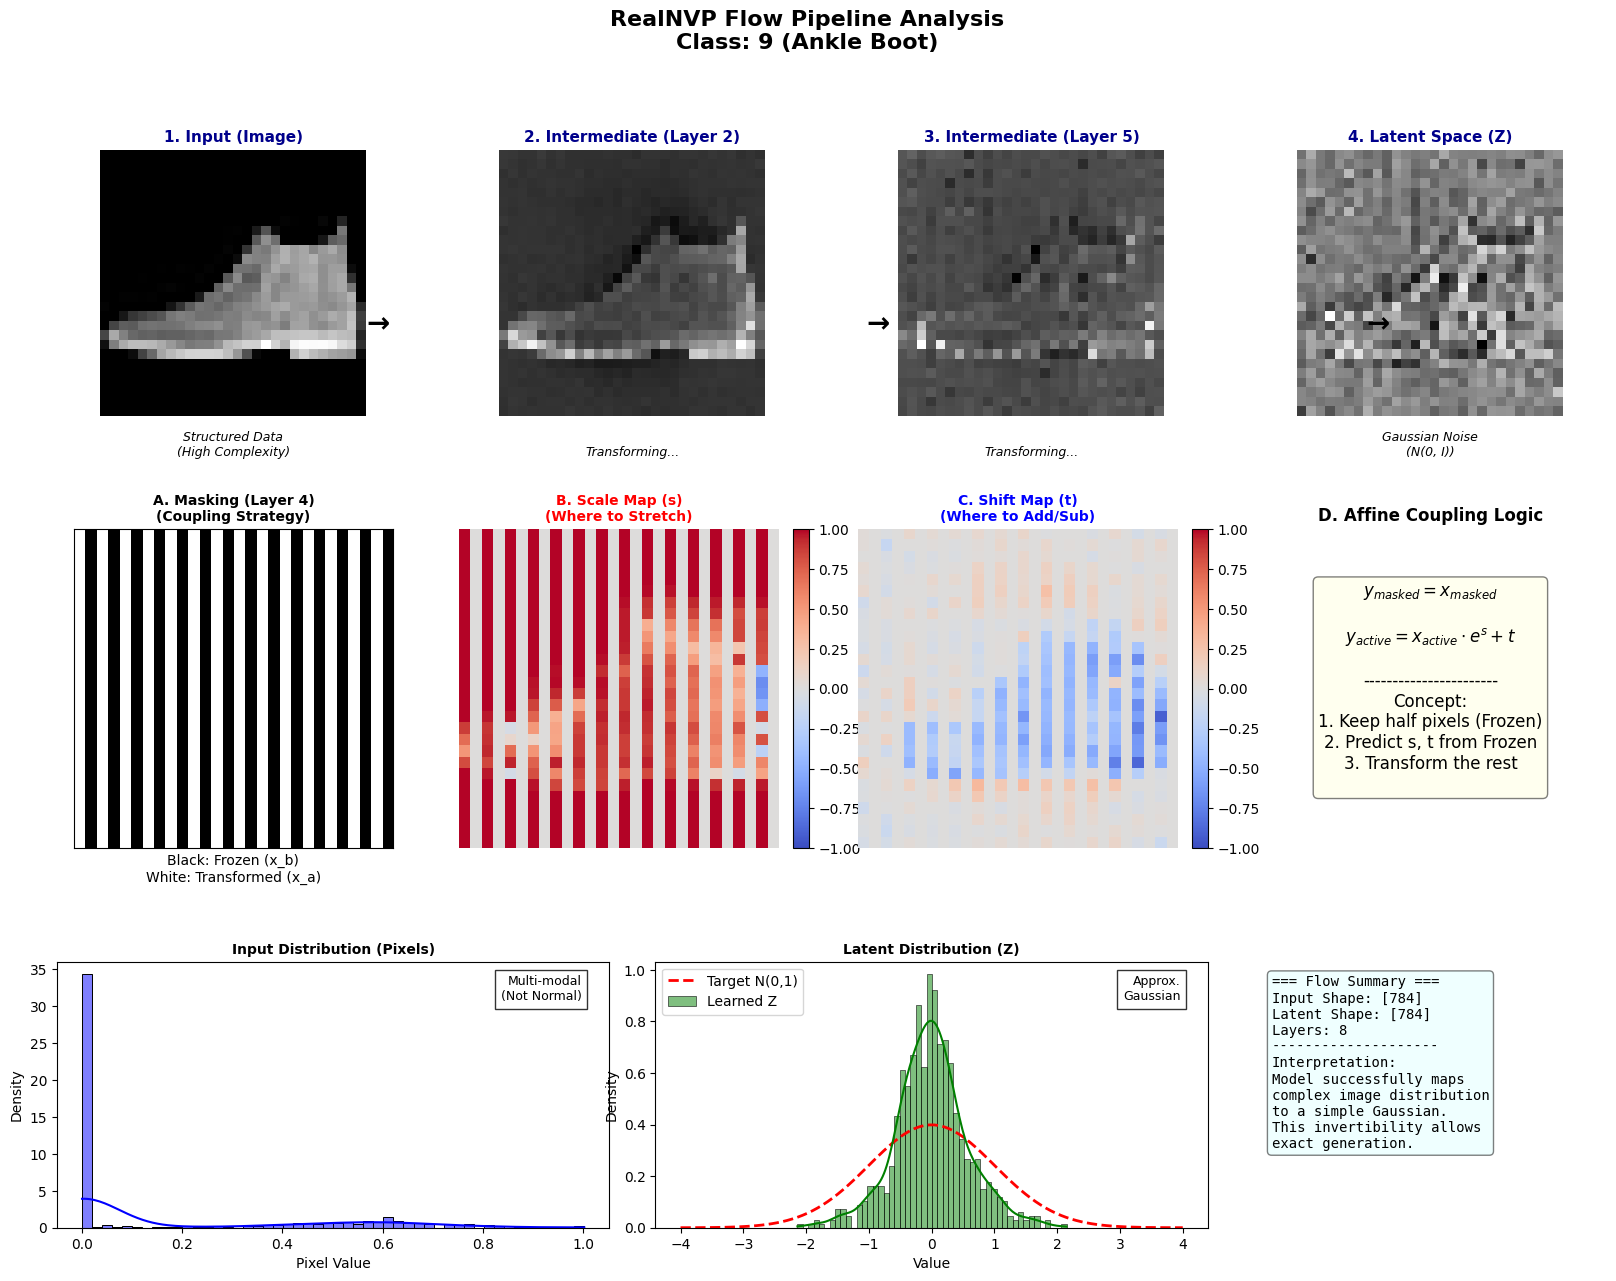

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os
import seaborn as sns # 데이터 분포 시각화를 위해 추가 (없으면 pip install seaborn)

# ==========================================
# 1. 설정 (Config)
# ==========================================
class Config:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 128
    LATENT_DIM = 784
    HIDDEN_DIM = 512
    NUM_LAYERS = 8
    NUM_CLASSES = 10
    DATA_ROOT = './data'

cfg = Config()

# ==========================================
# 2. 시각화용 모델 래퍼 (Pipeline Info 추출)
# ==========================================
class AffineCoupling_Pipeline(nn.Module):
    def __init__(self, input_dim, hidden_dim, mask, num_classes):
        super(AffineCoupling_Pipeline, self).__init__()
        self.register_buffer('mask', mask)
        in_channels = input_dim + num_classes
        self.net = nn.Sequential(
            nn.Linear(in_channels, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim * 2)
        )

    def forward(self, x, y_onehot):
        x_masked = x * self.mask
        net_input = torch.cat([x_masked, y_onehot], dim=1)
        out = self.net(net_input)
        s, t = out.chunk(2, dim=1)
        s = torch.tanh(s)

        # 마스킹 적용
        s = s * (1 - self.mask)
        t = t * (1 - self.mask)

        # 변환
        z = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)

        # 시각화 정보 리턴
        return z, {'s': s, 't': t, 'mask': self.mask}

class ConditionalRealNVP_Pipeline(nn.Module):
    def __init__(self, config):
        super(ConditionalRealNVP_Pipeline, self).__init__()
        self.layers = nn.ModuleList()
        self.input_dim = config.LATENT_DIM
        self.num_classes = config.NUM_CLASSES

        # 버퍼 등록 (저장된 모델 로드 호환성)
        self.register_buffer('prior_mean', torch.zeros(1))
        self.register_buffer('prior_var', torch.ones(1))

        mask_even = torch.tensor([1 if i % 2 == 0 else 0 for i in range(self.input_dim)], dtype=torch.float32)
        mask_odd = 1 - mask_even

        for i in range(config.NUM_LAYERS):
            mask = mask_even if i % 2 == 0 else mask_odd
            self.layers.append(AffineCoupling_Pipeline(self.input_dim, config.HIDDEN_DIM, mask, self.num_classes))

    def forward(self, x, y):
        y_onehot = torch.nn.functional.one_hot(y, num_classes=self.num_classes).float()

        pipeline_stats = []
        z = x

        # 초기 상태
        pipeline_stats.append({'img': z.detach().cpu(), 'info': None})

        for i, layer in enumerate(self.layers):
            z, info = layer(z, y_onehot)
            # 텐서 정보를 CPU로 이동
            info_cpu = {k: v.detach().cpu() for k, v in info.items()}
            pipeline_stats.append({'img': z.detach().cpu(), 'info': info_cpu})

        return pipeline_stats

# ==========================================
# 3. 종합 시각화 함수 (ViT 스타일)
# ==========================================
def visualize_flow_pipeline(model, sample_image, true_label, save_path=None):
    model.eval()

    # Forward Pass
    with torch.no_grad():
        x_gpu = sample_image.unsqueeze(0).to(cfg.DEVICE)
        y_gpu = true_label.unsqueeze(0).to(cfg.DEVICE)
        stats = model(x_gpu, y_gpu)

    # -------------------------------------------------
    # Figure Setup
    # -------------------------------------------------
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f"RealNVP Flow Pipeline Analysis\nClass: {true_label.item()} (Ankle Boot)",
                 fontsize=16, fontweight='bold')

    gs = gridspec.GridSpec(3, 8, height_ratios=[1, 1.2, 1], hspace=0.4, wspace=0.3)

    # =============================================
    # Row 1: The Transformation Pipeline (Input -> Noise)
    # =============================================
    # 처음, 중간(2개), 끝 단계를 보여줍니다.

    indices_to_show = [0, 2, 5, 8] # Input, Layer 2, Layer 5, Output
    titles = ["1. Input (Image)", "2. Intermediate (Layer 2)", "3. Intermediate (Layer 5)", "4. Latent Space (Z)"]

    for idx, list_idx in enumerate(indices_to_show):
        ax = fig.add_subplot(gs[0, idx*2 : idx*2+2])
        img_data = stats[list_idx]['img'].view(28, 28).numpy()

        ax.imshow(img_data, cmap='gray')
        ax.set_title(titles[idx], fontsize=11, fontweight='bold', color='darkblue')
        ax.axis('off')

        # 설명 텍스트
        if idx == 0:
            desc = "Structured Data\n(High Complexity)"
        elif idx == 3:
            desc = "Gaussian Noise\n(N(0, I))"
        else:
            desc = "Transforming..."

        ax.text(0.5, -0.15, desc, transform=ax.transAxes, ha='center', style='italic', fontsize=9)

    # 화살표 그리기 (Process Flow)
    fig.text(0.28, 0.75, "→", fontsize=20, fontweight='bold')
    fig.text(0.53, 0.75, "→", fontsize=20, fontweight='bold')
    fig.text(0.78, 0.75, "→", fontsize=20, fontweight='bold')

    # =============================================
    # Row 2: Anatomy of a Layer (Deep Dive into Layer 4)
    # =============================================
    # 특정 레이어(예: 4번 레이어)에서 무슨 일이 일어나는지 해부
    target_layer_idx = 4
    layer_info = stats[target_layer_idx]['info']

    # 2-1. Mask Pattern
    ax_mask = fig.add_subplot(gs[1, 0:2])
    mask_view = layer_info['mask'].view(28, 28).numpy()
    ax_mask.imshow(mask_view, cmap='binary', vmin=0, vmax=1)
    ax_mask.set_title(f"A. Masking (Layer {target_layer_idx})\n(Coupling Strategy)", fontsize=10, fontweight='bold')
    ax_mask.set_xlabel("Black: Frozen (x_b)\nWhite: Transformed (x_a)")
    ax_mask.set_xticks([])
    ax_mask.set_yticks([])

    # 2-2. Scale Map (s)
    ax_s = fig.add_subplot(gs[1, 2:4])
    s_view = layer_info['s'].view(28, 28).numpy()
    im_s = ax_s.imshow(s_view, cmap='coolwarm', vmin=-1, vmax=1)
    ax_s.set_title("B. Scale Map (s)\n(Where to Stretch)", fontsize=10, fontweight='bold', color='red')
    ax_s.axis('off')
    plt.colorbar(im_s, ax=ax_s, fraction=0.046, pad=0.04)

    # 2-3. Shift Map (t)
    ax_t = fig.add_subplot(gs[1, 4:6])
    t_view = layer_info['t'].view(28, 28).numpy()
    im_t = ax_t.imshow(t_view, cmap='coolwarm', vmin=-1, vmax=1)
    ax_t.set_title("C. Shift Map (t)\n(Where to Add/Sub)", fontsize=10, fontweight='bold', color='blue')
    ax_t.axis('off')
    plt.colorbar(im_t, ax=ax_t, fraction=0.046, pad=0.04)

    # 2-4. Transformation Formula
    ax_eq = fig.add_subplot(gs[1, 6:8])
    ax_eq.axis('off')
    formula = (
        r"$y_{masked} = x_{masked}$" + "\n\n" +
        r"$y_{active} = x_{active} \cdot e^s + t$" + "\n\n"
        "-----------------------\n"
        "Concept:\n"
        "1. Keep half pixels (Frozen)\n"
        "2. Predict s, t from Frozen\n"
        "3. Transform the rest\n"
    )
    ax_eq.text(0.5, 0.5, formula, ha='center', va='center', fontsize=12,
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    ax_eq.set_title("D. Affine Coupling Logic", fontweight='bold')

    # =============================================
    # Row 3: Statistical Analysis (Distribution Change)
    # =============================================

    # 3-1. Input Distribution
    ax_hist1 = fig.add_subplot(gs[2, 0:3])
    input_pixels = stats[0]['img'].numpy().flatten()
    sns.histplot(input_pixels, bins=50, kde=True, color='blue', ax=ax_hist1, stat='density')
    ax_hist1.set_title("Input Distribution (Pixels)", fontsize=10, fontweight='bold')
    ax_hist1.set_xlabel("Pixel Value")
    ax_hist1.text(0.95, 0.95, "Multi-modal\n(Not Normal)", transform=ax_hist1.transAxes,
                  ha='right', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

    # 3-2. Latent Distribution
    ax_hist2 = fig.add_subplot(gs[2, 3:6])
    output_pixels = stats[-1]['img'].numpy().flatten()

    # Standard Normal Reference
    x = np.linspace(-4, 4, 100)
    y = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)
    ax_hist2.plot(x, y, 'r--', linewidth=2, label='Target N(0,1)')

    sns.histplot(output_pixels, bins=50, kde=True, color='green', ax=ax_hist2, stat='density', label='Learned Z')
    ax_hist2.set_title("Latent Distribution (Z)", fontsize=10, fontweight='bold')
    ax_hist2.set_xlabel("Value")
    ax_hist2.legend()
    ax_hist2.text(0.95, 0.95, "Approx.\nGaussian", transform=ax_hist2.transAxes,
                  ha='right', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

    # 3-3. Summary Box
    ax_sum = fig.add_subplot(gs[2, 6:8])
    ax_sum.axis('off')
    summary_text = (
        "=== Flow Summary ===\n"
        f"Input Shape: [784]\n"
        f"Latent Shape: [784]\n"
        f"Layers: {cfg.NUM_LAYERS}\n"
        "--------------------\n"
        "Interpretation:\n"
        "Model successfully maps\n"
        "complex image distribution\n"
        "to a simple Gaussian.\n"
        "This invertibility allows\n"
        "exact generation."
    )
    ax_sum.text(0.05, 0.95, summary_text, transform=ax_sum.transAxes, va='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Saved visualization to {save_path}")

    plt.show()

# ==========================================
# 4. 실행 (Run)
# ==========================================
def main_viz():
    # 데이터 로더 준비
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x + torch.rand_like(x) / 256.0),
        transforms.Lambda(lambda x: x.view(-1))
    ])
    test_dataset = torchvision.datasets.FashionMNIST(root=cfg.DATA_ROOT, train=False, download=True, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    # 모델 로드
    model = ConditionalRealNVP_Pipeline(cfg).to(cfg.DEVICE)
    model_path = "best_flow_model.pth"

    if os.path.exists(model_path):
        print("📥 모델 로드 중...")
        model.load_state_dict(torch.load(model_path, map_location=cfg.DEVICE))
    else:
        print("⚠️ 저장된 모델이 없습니다. (시각화 예시를 위해 랜덤 가중치로 실행됩니다)")

    # 샘플 이미지 가져오기
    x_real, y_real = next(iter(test_loader))
    x_real = x_real[0] # (784,)
    y_real = y_real[0] # scalar

    print(f"🎨 파이프라인 시각화 생성 중... (Class {y_real.item()})")
    visualize_flow_pipeline(model, x_real, y_real, save_path="flow_pipeline_result.png")

if __name__ == "__main__":
    main_viz()

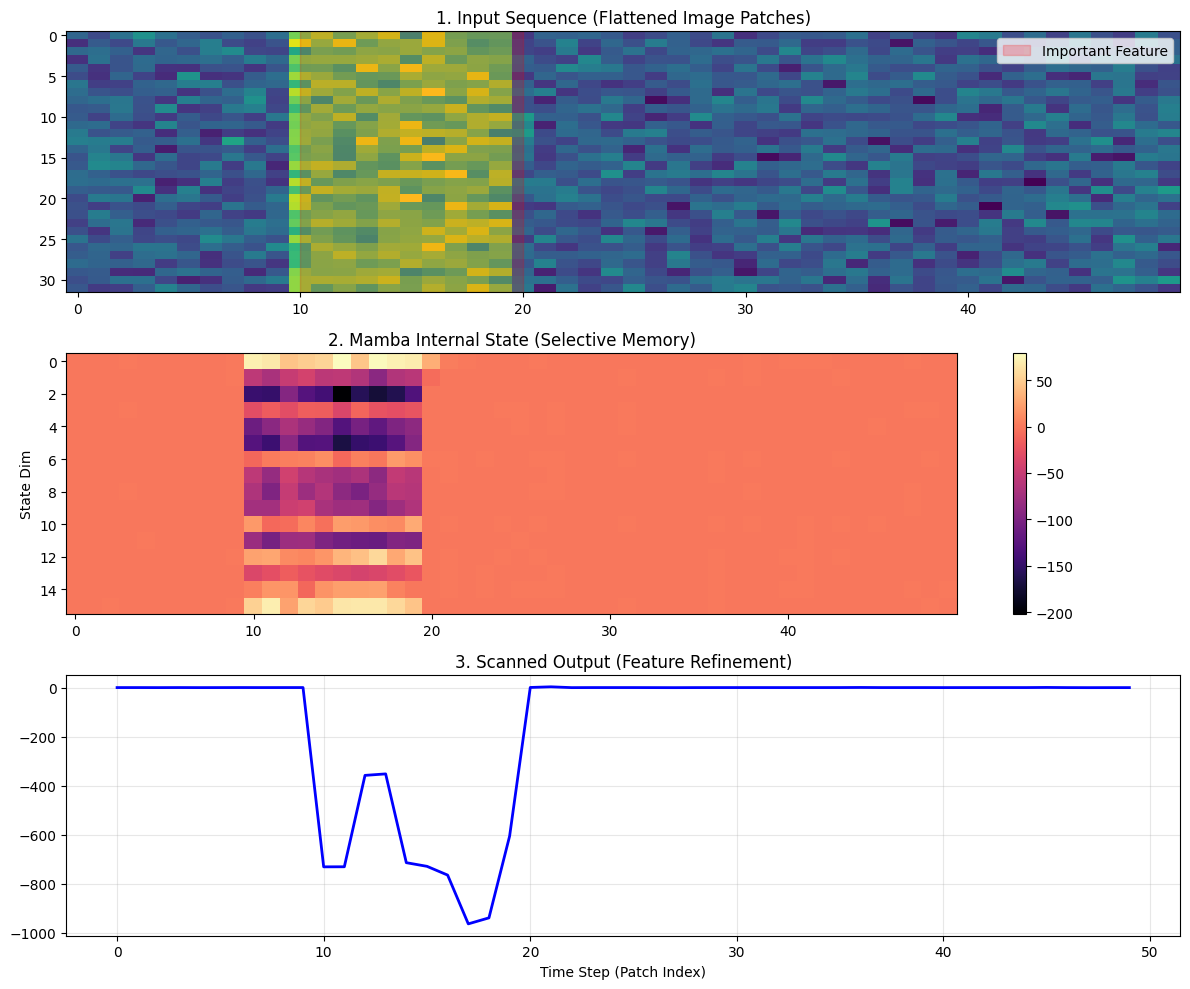

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Simple Mamba (SSM) Block 구현
# ==========================================
class SimpleMambaLayer(nn.Module):
    def __init__(self, d_model, d_state=16):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state

        # SSM 파라미터들 (A, B, C, delta)
        # 실제 Mamba는 이들을 입력 x에 따라 결정(Selective)합니다.
        self.x_proj = nn.Linear(d_model, d_state * 2 + 1) # B, C, delta를 뽑기 위한 투영
        self.A = nn.Parameter(torch.exp(torch.arange(1, d_state + 1))) # 상태 유지 매트릭스
        self.dt_proj = nn.Linear(1, d_model)

    def forward(self, x):
        # x: (Batch, Seq_len, Dim)
        batch, seq_len, dim = x.shape

        # 1. Selective 매개변수 추출
        proj = self.x_proj(x)
        B, C, delta = torch.split(proj, [self.d_state, self.d_state, 1], dim=-1)
        delta = F.softplus(delta) # 시간 간격 (얼마나 정보를 반영할지)

        # 2. SSM Scan (순차적 정보 처리)
        state = torch.zeros(batch, self.d_state).to(x.device) # 초기 상태 (Memory)
        preds = []
        state_history = [] # 시각화를 위해 저장

        for t in range(seq_len):
            # 현재 입력
            x_t = x[:, t, :]

            # Selective Scan 수식의 핵심:
            # 다음 상태 = (기존 상태 * 망각 계수) + (새로운 입력 * 입력 계수)
            # discretization (이산화) 과정을 거친 간략화된 형태
            dt = delta[:, t, :]
            dA = torch.exp(-self.A * dt) # 정보를 얼마나 잊을지
            dB = dt * B[:, t, :]         # 새로운 정보를 얼마나 넣을지

            state = dA * state + dB * x_t.mean(dim=-1, keepdim=True)

            # 출력 생성
            y_t = (state @ C[:, t, :].t()).diagonal()
            preds.append(y_t)
            state_history.append(state.detach().cpu().numpy())

        return torch.stack(preds, dim=1), np.array(state_history)

# ==========================================
# 2. 시각화 및 실행
# ==========================================
def visualize_mamba_logic():
    # 가상의 이미지 패치 시퀀스 (이미지를 1D로 펼쳤다고 가정)
    # 0~10 지점은 패턴이 있고, 나머지는 노이즈인 상황
    seq_len = 50
    d_model = 32
    x = torch.randn(1, seq_len, d_model)
    x[0, 10:20, :] += 5.0 # 특정 영역에 '중요한 특징(이상치 등)' 주입

    model = SimpleMambaLayer(d_model)
    output, states = model(x)

    # 시각화
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    # [1] Input Sequence
    axes[0].imshow(x[0].T, aspect='auto', cmap='viridis')
    axes[0].set_title("1. Input Sequence (Flattened Image Patches)")
    axes[0].axvspan(10, 20, color='red', alpha=0.2, label='Important Feature')
    axes[0].legend()

    # [2] Internal Hidden State (Memory)
    # Mamba가 시간에 따라 상태를 어떻게 압축해서 들고 가는지 보여줌
    state_viz = states[:, 0, :].T # (d_state, seq_len)
    im = axes[1].imshow(state_viz, aspect='auto', cmap='magma')
    axes[1].set_title("2. Mamba Internal State (Selective Memory)")
    axes[1].set_ylabel("State Dim")
    plt.colorbar(im, ax=axes[1])

    # [3] Output Signal
    axes[2].plot(output[0].detach().numpy(), label='Mamba Output', color='blue', linewidth=2)
    axes[2].set_title("3. Scanned Output (Feature Refinement)")
    axes[2].set_xlabel("Time Step (Patch Index)")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_mamba_logic()